# (6) The galaxy stellar mass function at z = 0: Subgrid_emu vs CosmoHydro_emu vs targets

**Question:** How do the two GSMF emulators compare with each other and with three z = 0
targets — **GAMA DR4** (Driver+22, observations), **Frontier-E** (the CRK-HACC simulation
run at the calibrated parameters) and **UniverseMachine DR1** (Behroozi+19, empirical
model)? And what exactly is the difference between the *subgrid* and the *cosmohydro*
emulators?

## Subgrid_emu vs CosmoHydro_emu — what is the same and what differs

Both packages emulate the **same statistic from the same physics model**: the CRK-HACC
galaxy-formation subgrid prescription, measured with the same HAVOCC pipeline
(`GalStellarMassFunction_624.txt`, column `GSMF_Aperture`: aperture stellar mass in M☉,
dn/dlog₁₀M* in (h⁻¹Mpc)⁻³ dex⁻¹), on the **same 16-bin mass grid** (5×10⁹–2.8×10¹¹ M☉),
at the **same mass resolution** (m_dm = 1.13×10⁹ M☉/h, m_gas = 2.1×10⁸ M☉/h).
They differ in the *simulation suite* they were trained on:

| | **Subgrid_emu** | **CosmoHydro_emu** |
|---|---|---|
| Training suite | 64 sims, L = 128 h⁻¹Mpc, 2×512³ (“SCIDAC 128 SG5”) | 100 sims, L = 400 h⁻¹Mpc, 2×1600³ (“400MPC 5SG+2COSMO”) |
| Volume per sim | (128)³ ≈ 2.1×10⁶ (h⁻¹Mpc)³ | (400)³ ≈ 6.4×10⁷ (h⁻¹Mpc)³ — **30× larger** |
| Varied parameters | 5 subgrid: κ_w, e_w, M_seed, v_kin, ε_kin | the same 5 **+ (ωₘ, σ₈)** |
| M_seed range | 0.6–1.2 ×10⁶ M☉ | 0.6–2.0 ×10⁶ M☉ |
| Cosmology | fixed (Frontier-E values) | varied inside ωₘ ∈ [0.12, 0.155], σ₈ ∈ [0.7, 0.9] |
| Redshift | z = 0 only | z = 0–2 (11 snapshots, linear interpolation in z) |
| Emulator | SEPIA GP on PCA basis; predicts φ, δ-method std | SEPIA GP on PCA basis of log₁₀φ per snapshot |

So at **z = 0 and at the fiducial cosmology** (ωₘ = 0.14176, σ₈ = 0.8102 — the cosmology
of the subgrid suite) the two emulators should agree up to (i) sample variance of the
small boxes at the massive end, (ii) the different experimental designs, and
(iii) GP interpolation error. Everything that depends on cosmology, or on z > 0, is
available **only** from CosmoHydro_emu.

## Targets

- **GAMA DR4** (Driver+22): observed GSMF, loaded in the Inference-pipeline convention
  (`load_obs_data.load_gsmf_driver2022`, φ/h³ → (h⁻¹Mpc)⁻³).
- **Frontier-E**: the *Frontier-E-Small* precursor (L = 256 h⁻¹Mpc, identical resolution
  and subgrid parameters; HAVOCC extract copied to `../data_sims/frontier_e_small/`) —
  the same measurement definition the emulators were trained on, so this is the cleanest
  emulator test. The survey-scale 3150 h⁻¹Mpc run enters through an OpenCosmo galaxy
  query for the massive end (last section; skips if the catalog file is absent).
- **UniverseMachine DR1** (Behroozi+19): best-fit z = 0 SMF from the empirical model, the
  file bundled with HAVOCC, converted to (h⁻¹Mpc)⁻³ dex⁻¹
  (`load_obs_data.load_gsmf_universemachine`).

All parameters come from `../fixed_parameters.txt` (v_kin at the exact simulated value
`v_kin_sim` = 0.51, as in nb4).

In [1]:
import warnings
warnings.filterwarnings('ignore')
import os, sys, glob
import numpy as np
import matplotlib.pyplot as plt

import cosmohydro_emu as ce
import subgrid_emu as sge

sys.path.insert(0, '../data_observational')
import load_obs_data as obs

%matplotlib inline
plt.rcParams.update({'font.size': 12, 'figure.dpi': 100})

In [2]:
def load_fixed_params(path='../fixed_parameters.txt'):
    params = {}
    with open(path) as f:
        for line in f:
            line = line.split('#')[0].strip()
            if '=' in line:
                key, val = [s.strip() for s in line.split('=')]
                try:
                    params[key] = float(val)
                except ValueError:
                    params[key] = val
    return params

FP = load_fixed_params()
h = FP['h']
P5 = [FP['kappa_w'], FP['e_w'], FP['M_seed'], FP['v_kin_sim'], FP['epsilon_kin']]
P_COSMO = [FP['omega_m'], FP['sigma_8']]
P7 = P5 + P_COSMO
P5_NAMES = [r'$\kappa_w$', r'$e_w$', r'$M_{seed}/10^6$', r'$v_{kin}/10^4$', r'$\epsilon_{kin}/10$']

ch = ce.load_emulator('GSMF')
sg = sge.load_emulator('GSMF')
x_ch = np.asarray(ce.get_x_grid('GSMF')[0])
x_sg = np.asarray(sge.get_x_grid('GSMF')[0])
assert np.allclose(x_ch, x_sg), 'mass grids differ'
x = x_ch

# what the two packages say about themselves
sg_info = sge.get_parameter_info()
print('Subgrid_emu   : params', sg_info['names'])
print('                ranges', sg_info['ranges'])
print('CosmoHydro_emu: params', ch.param_keys)
print('                design', ch.design.shape, 'lo', ch.design.min(0), 'hi', ch.design.max(0))
print('                redshifts', np.round(ch.redshifts, 3))
print('mass grid: %d bins, %.2e - %.2e Msun' % (len(x), x.min(), x.max()))
print('P5 (Frontier-E) =', P5, '  cosmology =', P_COSMO)

def pred_ch(p5=P5, cosmo=P_COSMO, z=0.0):
    m, s = ch.predict(list(p5) + list(cosmo), z=z)
    return m, s

def pred_sg(p5=P5):
    m, s = sg.predict(list(p5))
    return m, s

ch_m, ch_s = pred_ch()
sg_m, sg_s = pred_sg()

Subgrid_emu   : params ['kappa_w', 'e_w', 'M_seed', 'v_kin', 'epsilon_kin']
                ranges {'kappa_w': (2.0, 4.0), 'e_w': (0.2, 1.0), 'M_seed': (0.6, 1.2), 'v_kin': (0.1, 1.2), 'epsilon_kin': (0.02, 1.2)}
CosmoHydro_emu: params ['kappa_w', 'e_w', 'M_seed', 'v_kin', 'epsilon_kin', 'omega_m', 'sigma_8']
                design (100, 7) lo [2.   0.2  0.6  0.1  0.02 0.12 0.7 ] hi [4.    1.    2.    1.2   1.2   0.155 0.9  ]
                redshifts [0.    0.1   0.251 0.3   0.499 0.749 1.    1.25  1.501 1.753 2.004]
mass grid: 16 bins, 5.15e+09 - 2.77e+11 Msun
P5 (Frontier-E) = [3.0, 0.5, 0.8, 0.51, 0.13]   cosmology = [0.14176, 0.8102]


## Targets

In [3]:
gama = obs.load_gsmf_driver2022()
um = obs.load_gsmf_universemachine(hubble=h)

# Frontier-E-Small, z = 0 (step 624): M* [Msun], dn/dlogM* [(Mpc/h)^-3 dex^-1], Poisson err
d = np.loadtxt('../data_sims/frontier_e_small/GalStellarMassFunction_624.txt')
mfe = d[:, 1] > 0
fes = {'x': d[mfe, 0], 'y': d[mfe, 1], 'yerr': d[mfe, 2],
       'label': 'Frontier-E-Small (256 $h^{-1}$Mpc), z = 0'}
# the same file also carries HAVOCC's own UM column -- used below only as a cross-check
fes_um_col = d[:, 4]

targets = [('GAMA', gama, 'k', 'o'), ('Frontier-E-Small', fes, 'darkorange', 's'),
           ('UniverseMachine', um, 'seagreen', None)]
for name, t, _, _ in targets:
    print(f"{name:18s} {t['label']:45s} M* = {t['x'].min():.1e} - {t['x'].max():.1e}  ({len(t['x'])} pts)")

# cross-check: our UM loader vs HAVOCC's GSMF_UM_z0.00 column, on the sim file's own grid
okc = (fes_um_col > 0) & (d[:, 0] >= 1e9) & (d[:, 0] <= 1e12)
um_ok = um['y'] > 0
um_i = 10**np.interp(np.log10(d[okc, 0]), np.log10(um['x'][um_ok]), np.log10(um['y'][um_ok]))
print('UM loader vs HAVOCC GSMF_UM column: max |dlog10 phi| = %.3f  (1e9 < M* < 1e12)'
      % np.abs(np.log10(um_i / fes_um_col[okc])).max())

GAMA               GAMA DR4 (Driver+22)                          M* = 2.4e+06 - 4.2e+11  (21 pts)
Frontier-E-Small   Frontier-E-Small (256 $h^{-1}$Mpc), z = 0     M* = 1.0e+09 - 1.8e+12  (29 pts)
UniverseMachine    UniverseMachine DR1 (Behroozi+19), z = 0      M* = 2.0e+07 - 1.3e+13  (30 pts)
UM loader vs HAVOCC GSMF_UM column: max |dlog10 phi| = 0.078  (1e9 < M* < 1e12)


## A. Fiducial comparison: both emulators at the Frontier-E parameters vs the three targets

Top: emulator means with ±2σ bands, targets with their errors. Bottom: ratio of each
emulator to each target, on the emulator mass grid (targets interpolated in log–log).
The grey band is ±10 %.

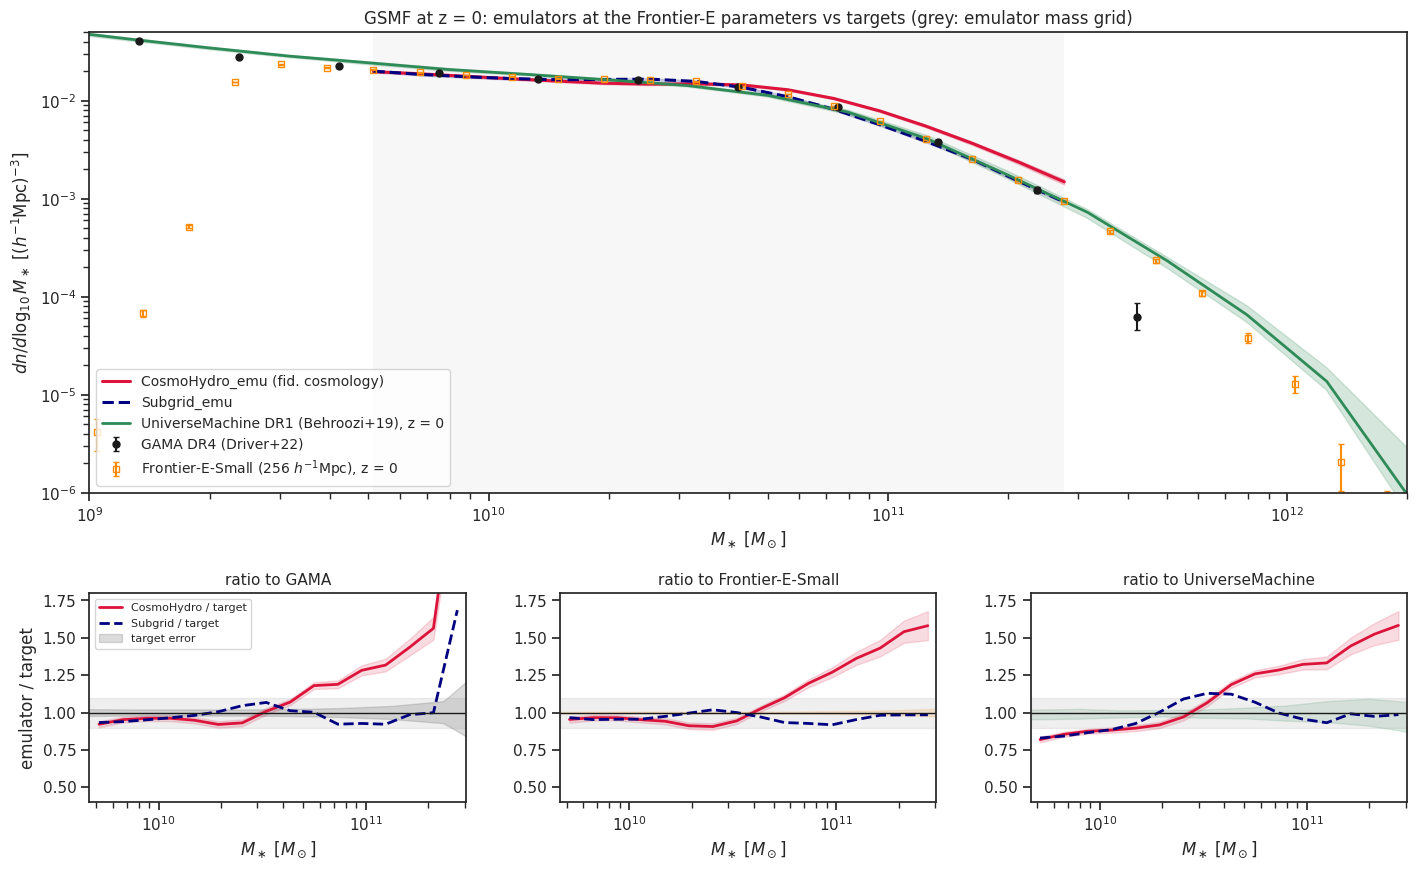

In [4]:
def _prep(t):
    # sorted by mass, positive densities only (GAMA is stored high->low, UM has empty top bins)
    e = t['yerr']; elo, ehi = (e[0], e[1]) if isinstance(e, tuple) else (e, e)
    ok = t['y'] > 0
    o = np.argsort(t['x'][ok])
    return t['x'][ok][o], t['y'][ok][o], np.asarray(elo)[ok][o], np.asarray(ehi)[ok][o]

def interp_target(t, xg):
    tx, ty, _, _ = _prep(t)
    return 10**np.interp(np.log10(xg), np.log10(tx), np.log10(ty), left=np.nan, right=np.nan)

fig = plt.figure(figsize=(17, 10))
gs = fig.add_gridspec(2, 3, height_ratios=[2.2, 1], hspace=0.3, wspace=0.25)
ax = fig.add_subplot(gs[0, :])
ax.plot(x, ch_m, color='crimson', lw=2.2, label='CosmoHydro_emu (fid. cosmology)')
ax.fill_between(x, ch_m - 2*ch_s, ch_m + 2*ch_s, color='crimson', alpha=0.2)
ax.plot(x, sg_m, color='navy', lw=2.2, ls='--', label='Subgrid_emu')
ax.fill_between(x, sg_m - 2*sg_s, sg_m + 2*sg_s, color='navy', alpha=0.15)
ax.errorbar(gama['x'], gama['y'], yerr=gama['yerr'], fmt='o', ms=5, color='k', capsize=2, label=gama['label'])
ax.errorbar(fes['x'], fes['y'], yerr=fes['yerr'], fmt='s', ms=4, color='darkorange', mfc='none',
            capsize=2, label=fes['label'])
ax.plot(um['x'], um['y'], color='seagreen', lw=2, label=um['label'])
ax.fill_between(um['x'], um['y'] - um['yerr'][0], um['y'] + um['yerr'][1], color='seagreen', alpha=0.2)
ax.axvspan(x.min(), x.max(), color='gray', alpha=0.06, lw=0)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlim(1e9, 2e12); ax.set_ylim(1e-6, 5e-2)
ax.set_xlabel(r'$M_\ast\;[M_\odot]$'); ax.set_ylabel(r'$dn/d\log_{10}M_\ast\;[(h^{-1}{\rm Mpc})^{-3}]$')
ax.set_title('GSMF at z = 0: emulators at the Frontier-E parameters vs targets (grey: emulator mass grid)')
ax.legend(fontsize=10, loc='lower left')

for j, (name, t, c, mk) in enumerate(targets):
    axr = fig.add_subplot(gs[1, j])
    ti = interp_target(t, x)
    axr.plot(x, ch_m / ti, color='crimson', lw=2, label='CosmoHydro / target')
    axr.fill_between(x, (ch_m - 2*ch_s) / ti, (ch_m + 2*ch_s) / ti, color='crimson', alpha=0.15)
    axr.plot(x, sg_m / ti, color='navy', lw=2, ls='--', label='Subgrid / target')
    # target's own relative error band around 1
    tx, ty, elo, ehi = _prep(t)
    axr.fill_between(tx, 1 - elo / ty, 1 + ehi / ty, color=c, alpha=0.15, label='target error')
    axr.axhline(1, color='k', lw=1); axr.axhspan(0.9, 1.1, color='gray', alpha=0.12)
    axr.set_xscale('log'); axr.set_xlim(x.min() * 0.9, x.max() * 1.1); axr.set_ylim(0.4, 1.8)
    axr.set_title(f'ratio to {name}', fontsize=11); axr.set_xlabel(r'$M_\ast\;[M_\odot]$')
    if j == 0:
        axr.set_ylabel('emulator / target'); axr.legend(fontsize=8, loc='upper left')
plt.show()

## B. Response to the subgrid parameters (both emulators) against the targets

One-at-a-time sweeps across the range common to both packages (M_seed ≤ 1.2×10⁶ M☉),
others held at the Frontier-E values. Solid: CosmoHydro_emu, dashed: Subgrid_emu.
The printed table gives the *lever arm* of each parameter — the spread in log₁₀φ across
the sweep at M* = 10¹⁰ and 10¹¹ M☉ — for both emulators.

parameter               range   CH spread@1e10 SG spread@1e10   CH spread@1e11 SG spread@1e11   [dex]


$\kappa_w$        2.00- 4.00            0.049          0.045            0.159          0.187


$e_w$             0.20- 1.00            0.225          0.233            0.224          0.207


$M_{seed}/10^6$   0.60- 1.20            0.035          0.055            0.138          0.164


$v_{kin}/10^4$    0.10- 1.20            0.002          0.005            0.004          0.003


$\epsilon_{kin}/10$  0.02- 1.20            0.005          0.024            0.052          0.007


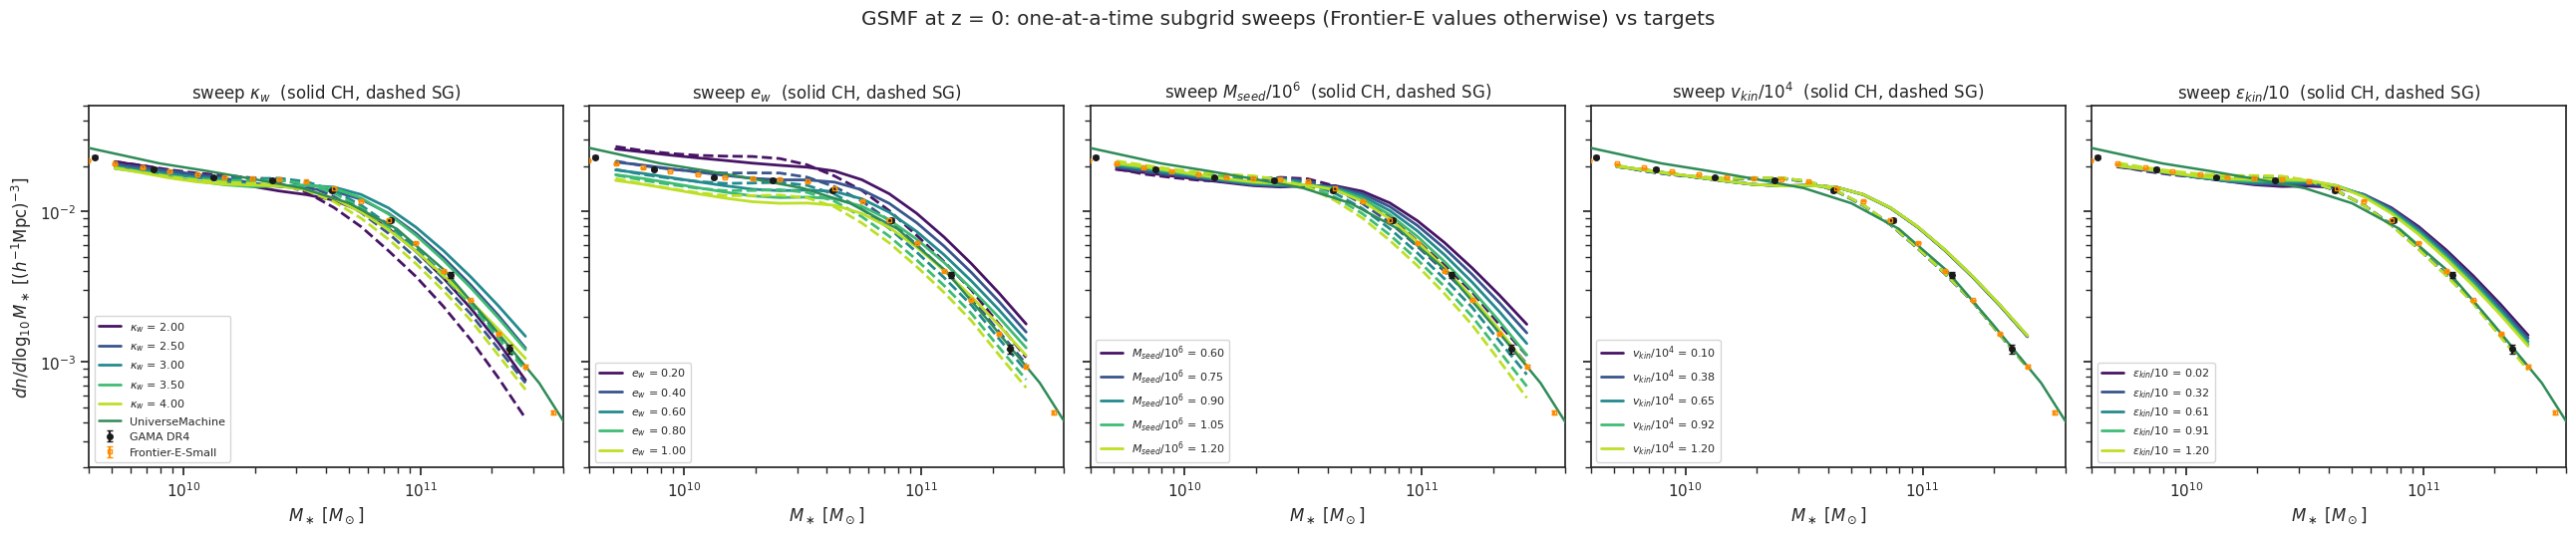

In [5]:
SWEEP = [(2.0, 4.0), (0.2, 1.0), (0.6, 1.2), (0.1, 1.2), (0.02, 1.2)]
N_SWEEP = 5
i10, i11 = np.argmin(np.abs(np.log10(x) - 10)), np.argmin(np.abs(np.log10(x) - 11))

def draw_targets(ax, legend=False):
    ax.errorbar(gama['x'], gama['y'], yerr=gama['yerr'], fmt='o', ms=4, color='k', capsize=2,
                label='GAMA DR4' if legend else None, zorder=5)
    ax.errorbar(fes['x'], fes['y'], yerr=fes['yerr'], fmt='s', ms=3.5, color='darkorange', mfc='none',
                capsize=2, label='Frontier-E-Small' if legend else None, zorder=5)
    ax.plot(um['x'], um['y'], color='seagreen', lw=1.8, label='UniverseMachine' if legend else None, zorder=4)

fig, axes = plt.subplots(1, 5, figsize=(26, 5.2), sharey=True)
print(f"{'parameter':16s} {'range':>12s}   {'CH spread@1e10':>14s} {'SG spread@1e10':>14s}   {'CH spread@1e11':>14s} {'SG spread@1e11':>14s}   [dex]")
for i, (ax, (lo, hi), name) in enumerate(zip(axes, SWEEP, P5_NAMES)):
    vals = np.linspace(lo, hi, N_SWEEP)
    cols = plt.cm.viridis(np.linspace(0.05, 0.9, N_SWEEP))
    L_ch, L_sg = [], []
    for v, c in zip(vals, cols):
        p5 = list(P5); p5[i] = v
        m_ch, _ = pred_ch(p5); m_sg, _ = pred_sg(p5)
        L_ch.append(np.log10(m_ch)); L_sg.append(np.log10(m_sg))
        ax.plot(x, m_ch, color=c, lw=2, label=f'{name} = {v:.2f}')
        ax.plot(x, m_sg, color=c, lw=2, ls='--')
    L_ch, L_sg = np.array(L_ch), np.array(L_sg)
    draw_targets(ax, legend=(i == 0))
    ax.set_xscale('log'); ax.set_yscale('log'); ax.set_ylim(2e-4, 5e-2); ax.set_xlim(4e9, 4e11)
    ax.set_xlabel(r'$M_\ast\;[M_\odot]$'); ax.set_title(f'sweep {name}  (solid CH, dashed SG)')
    ax.legend(fontsize=8, loc='lower left')
    print(f"{name:16s} {lo:5.2f}-{hi:5.2f}   {np.ptp(L_ch[:, i10]):14.3f} {np.ptp(L_sg[:, i10]):14.3f}   "
          f"{np.ptp(L_ch[:, i11]):14.3f} {np.ptp(L_sg[:, i11]):14.3f}")
axes[0].set_ylabel(r'$dn/d\log_{10}M_\ast\;[(h^{-1}{\rm Mpc})^{-3}]$')
plt.suptitle('GSMF at z = 0: one-at-a-time subgrid sweeps (Frontier-E values otherwise) vs targets', y=1.03)
plt.tight_layout(); plt.show()

## C. Response to cosmology (CosmoHydro_emu only)

Subgrid_emu has no cosmology axis; CosmoHydro_emu lets us ask how much of a GSMF shift a
plausible change in (ωₘ, σ₈) produces compared with the subgrid lever arms above. Left:
σ₈ varied at fixed ωₘ; right: ωₘ varied at fixed σ₈ (subgrid at the Frontier-E values).
Lower panels: ratio to the fiducial prediction.

sigma_8  across box: spread in log10 phi = 0.041 dex @1e10, 0.024 dex @1e11


omega_m  across box: spread in log10 phi = 0.042 dex @1e10, 0.036 dex @1e11


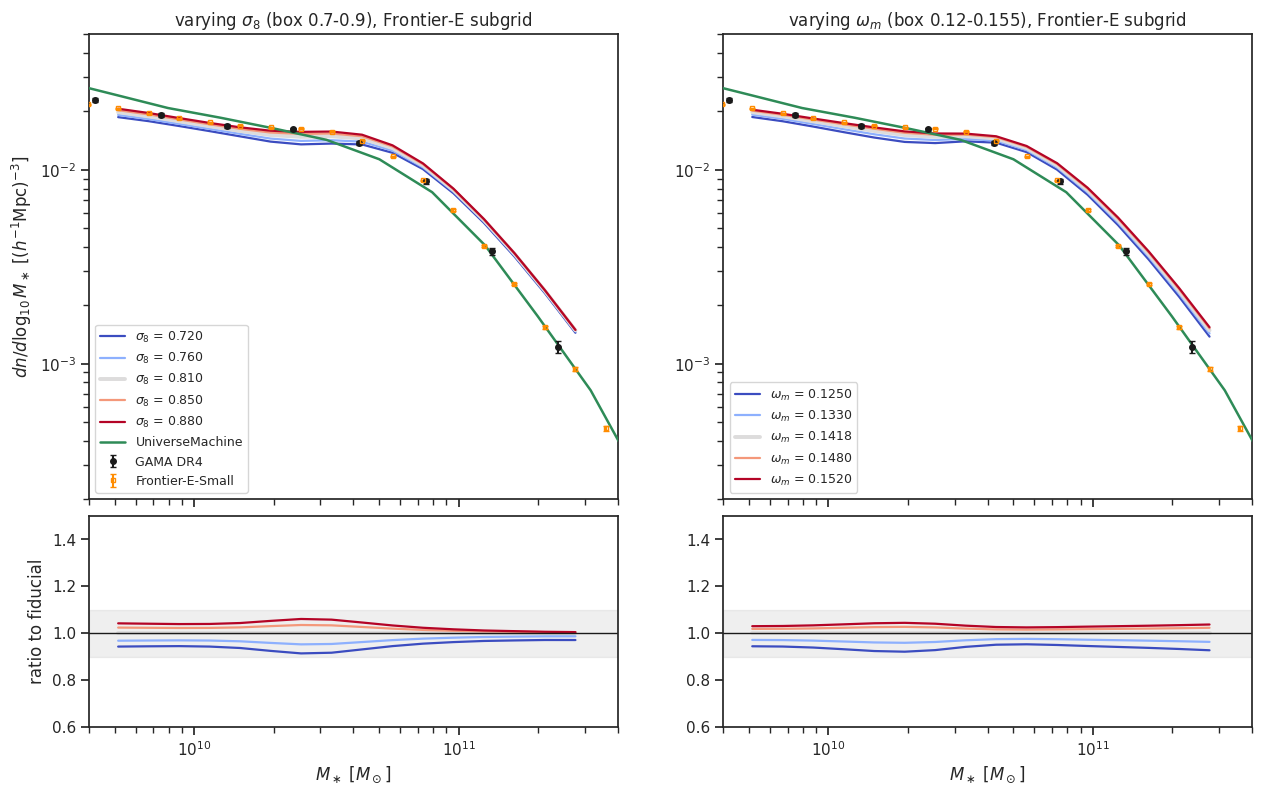

In [6]:
S8_LIST = [0.72, 0.76, FP['sigma_8'], 0.85, 0.88]
OM_LIST = [0.125, 0.133, FP['omega_m'], 0.148, 0.152]

fig, axes = plt.subplots(2, 2, figsize=(15, 9), sharex=True,
                         gridspec_kw={'height_ratios': [2.2, 1], 'hspace': 0.05})
for j, (vals, key) in enumerate([(S8_LIST, 's8'), (OM_LIST, 'om')]):
    ax, axr = axes[0, j], axes[1, j]
    cols = plt.cm.coolwarm(np.linspace(0, 1, len(vals)))
    spread10, spread11 = [], []
    for v, c in zip(vals, cols):
        cosmo = [FP['omega_m'], v] if key == 's8' else [v, FP['sigma_8']]
        m, _ = pred_ch(P5, cosmo)
        lab = (r'$\sigma_8$ = %.3f' if key == 's8' else r'$\omega_m$ = %.4f') % v
        lw = 2.8 if v in (FP['sigma_8'], FP['omega_m']) else 1.6
        ax.plot(x, m, color=c, lw=lw, label=lab)
        axr.plot(x, m / ch_m, color=c, lw=lw)
        spread10.append(np.log10(m[i10])); spread11.append(np.log10(m[i11]))
    draw_targets(ax, legend=(j == 0))
    ax.set_xscale('log'); ax.set_yscale('log'); ax.set_ylim(2e-4, 5e-2); ax.set_xlim(4e9, 4e11)
    ax.legend(fontsize=9, loc='lower left')
    ax.set_title(('varying $\\sigma_8$ (box 0.7-0.9)' if key == 's8' else 'varying $\\omega_m$ (box 0.12-0.155)')
                 + ', Frontier-E subgrid')
    axr.axhline(1, color='k', lw=1); axr.axhspan(0.9, 1.1, color='gray', alpha=0.12)
    axr.set_ylim(0.6, 1.5); axr.set_xlabel(r'$M_\ast\;[M_\odot]$')
    print(f"{'sigma_8' if key == 's8' else 'omega_m':8s} across box: spread in log10 phi = "
          f"{np.ptp(spread10):.3f} dex @1e10, {np.ptp(spread11):.3f} dex @1e11")
axes[0, 0].set_ylabel(r'$dn/d\log_{10}M_\ast\;[(h^{-1}{\rm Mpc})^{-3}]$')
axes[1, 0].set_ylabel('ratio to fiducial')
plt.show()

## D. Numbers: emulator–target and emulator–emulator agreement

For each pair, the RMS of log₁₀(emulator / target) over the overlapping mass range, the
maximum |log₁₀ ratio|, and a reduced χ² that uses the target's error and the emulator's
GP standard deviation in quadrature. The GAMA and UniverseMachine "errors" are
observational / model uncertainties, the Frontier-E-Small error is Poisson only (no
sample variance), so its χ² is the strictest.

In [7]:
def compare(m, s, t):
    ti = interp_target(t, x)
    tx, ty, elo, ehi = _prep(t)
    te = 10**np.interp(np.log10(x), np.log10(tx), np.log10(0.5 * (elo + ehi)), left=np.nan, right=np.nan)
    ok = np.isfinite(ti) & np.isfinite(te)
    dl = np.log10(m[ok] / ti[ok])
    chi2 = np.mean((m[ok] - ti[ok])**2 / (te[ok]**2 + s[ok]**2))
    return dl.std() if len(dl) else np.nan, np.abs(dl).max(), chi2, ok.sum()

rows = []
print(f"{'emulator':16s} {'target':18s} {'N':>3s} {'RMS dlog10':>11s} {'max|dlog10|':>12s} {'chi2/N':>8s}")
for ename, m, s in [('CosmoHydro_emu', ch_m, ch_s), ('Subgrid_emu', sg_m, sg_s)]:
    for tname, t, _, _ in targets:
        rms, mx, chi2, n = compare(m, s, t)
        print(f'{ename:16s} {tname:18s} {n:3d} {rms:11.3f} {mx:12.3f} {chi2:8.2f}')
dl = np.log10(ch_m / sg_m)
print(f"{'CosmoHydro_emu':16s} {'Subgrid_emu':18s} {len(x):3d} {dl.std():11.3f} {np.abs(dl).max():12.3f} "
      f"{np.mean((ch_m - sg_m)**2 / (ch_s**2 + sg_s**2)):8.2f}")
print('\nCH / SG ratio per mass bin:')
for xi, r in zip(x, ch_m / sg_m):
    print(f'  M* = {xi:.2e}  CH/SG = {r:.3f}')

emulator         target               N  RMS dlog10  max|dlog10|   chi2/N
CosmoHydro_emu   GAMA                16       0.119        0.432    30.47
CosmoHydro_emu   Frontier-E-Small    16       0.083        0.199    83.97
CosmoHydro_emu   UniverseMachine     16       0.096        0.200    21.94
Subgrid_emu      GAMA                16       0.060        0.227     5.06
Subgrid_emu      Frontier-E-Small    16       0.012        0.037     8.93
Subgrid_emu      UniverseMachine     16       0.041        0.081     8.22
CosmoHydro_emu   Subgrid_emu         16       0.086        0.206    95.35

CH / SG ratio per mass bin:
  M* = 5.15e+09  CH/SG = 0.988
  M* = 6.71e+09  CH/SG = 1.014
  M* = 8.76e+09  CH/SG = 1.011
  M* = 1.14e+10  CH/SG = 0.996
  M* = 1.49e+10  CH/SG = 0.967
  M* = 1.94e+10  CH/SG = 0.915
  M* = 2.53e+10  CH/SG = 0.890
  M* = 3.31e+10  CH/SG = 0.944
  M* = 4.31e+10  CH/SG = 1.057
  M* = 5.62e+10  CH/SG = 1.178
  M* = 7.33e+10  CH/SG = 1.289
  M* = 9.57e+10  CH/SG = 1.383
  M* = 

## E. The survey-scale Frontier-E GSMF (OpenCosmo portal) over the full mass range

Galaxy queries on the full 3150 h⁻¹Mpc Frontier-E run at z = 0 are stored as small
histograms in `../data_sims/frontier_e/catalogs/` (run ids inside the files):

| file | portal filter | rows | role |
|---|---|---|---|
| `*_gt3e9_subsample_hist.npz` | M* > 3×10⁹ M☉ | capped at 5×10⁶ | shape over the whole emulator grid |
| `*_gt2e11_subsample_hist.npz` | M* > 2×10¹¹ M☉ | capped at 5×10⁶ | intermediate normalisation step |
| `*_gt1e12_complete_hist.npz` | M* > 10¹² M☉ | uncapped (complete) | absolute normalisation |

The 5×10⁶-row cap does **not** cut the box spatially (the returned galaxies fill all 32 768
level-5 octree cells), so each capped query is a mass-independent random subsample with an
unknown fraction f. f is measured on the overlap with the next, better-sampled query and is
checked bin by bin for mass independence. The GSMF is counts / (f · L³ · Δlog₁₀M*), using
the best-sampled source in each mass range. Portal mass filters are in M☉; the catalog
stores M☉/h (HAVOCC convention, divided out when the histograms were made). With
31 (Gpc/h)³ the survey-scale run has negligible sample variance, so this is the reference
Frontier-E GSMF for both emulators and the two observational/empirical targets.
**Skips gracefully if the files are absent.**

f(>2e11 query) = 0.4968   per-bin (12-12.4 dex): [0.496 0.492 0.495 0.495 0.508 0.488 0.51  0.492]
f(>3e9 query)  = 0.00622   per-bin (11.3-12 dex): [0.00618 0.00628 0.00616 0.00624 0.00613 0.00622 0.00644]
implied full-box counts: N(>3e9) = 8.042e+08, N(>2e11) = 1.007e+07, N(>1e12) = 38877


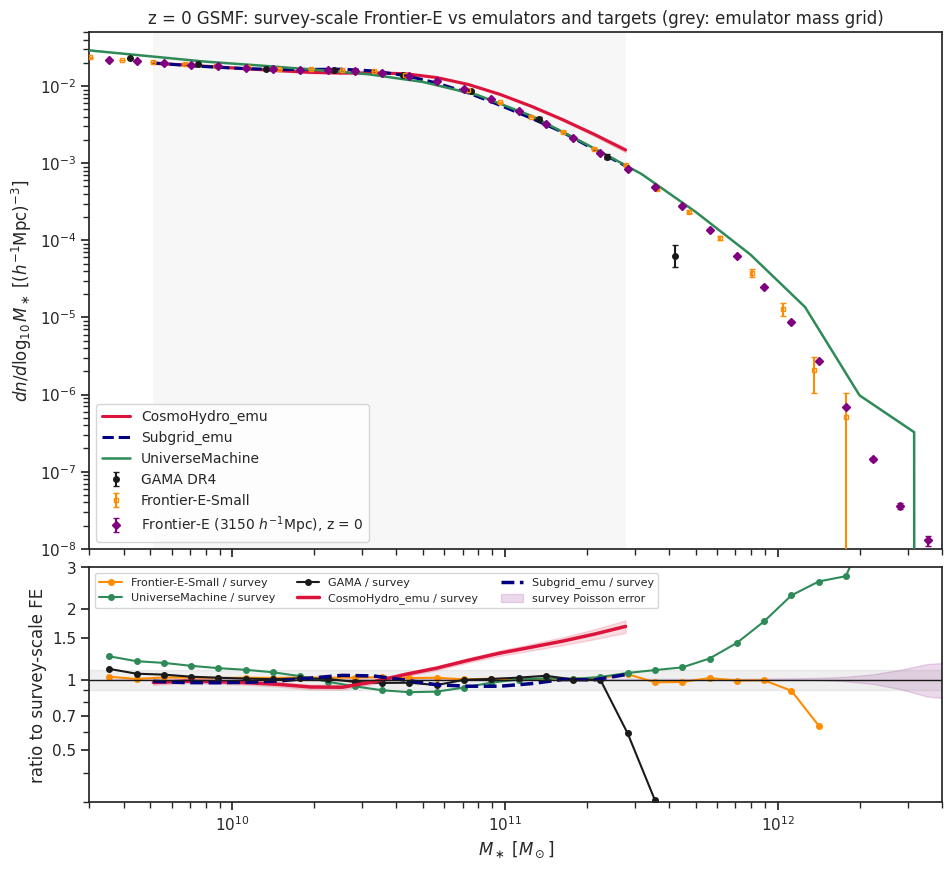


ratios to the survey-scale Frontier-E GSMF on the emulator grid:
 M* [Msun]   CH/FE   SG/FE  FE-Small/FE  GAMA/FE   UM/FE
  5.15e+09   0.971   0.983        1.017    1.053   1.184
  6.71e+09   0.984   0.970        1.018    1.033   1.151
  8.76e+09   0.979   0.969        1.014    1.018   1.119
  1.14e+10   0.969   0.973        1.018    1.008   1.098
  1.49e+10   0.953   0.986        1.012    1.005   1.064
  1.94e+10   0.929   1.015        1.019    1.009   1.013
  2.53e+10   0.927   1.041        1.022    0.995   0.955
  3.31e+10   0.978   1.035        1.035    0.970   0.917
  4.31e+10   1.051   0.994        1.025    0.982   0.885
  5.62e+10   1.118   0.949        1.017    0.947   0.888
  7.33e+10   1.207   0.936        1.010    1.015   0.939
  9.57e+10   1.295   0.936        1.019    1.010   0.979
  1.25e+11   1.373   0.960        1.008    1.042   1.030
  1.63e+11   1.457   1.000        1.018    1.014   1.008
  2.12e+11   1.559   0.996        1.012    0.997   1.023
  2.77e+11   1.683   1

In [8]:
CAT_DIR = '../data_sims/frontier_e/catalogs'
files = {k: f'{CAT_DIR}/frontier_e_z0_mstar_{k}_hist.npz'
         for k in ['gt3e9_subsample', 'gt2e11_subsample', 'gt1e12_complete']}
if not all(os.path.exists(f) for f in files.values()):
    print('survey-scale Frontier-E histograms not found -- section skipped'); fe_survey = None
else:
    H = {k: np.load(f) for k, f in files.items()}
    L = float(H['gt1e12_complete']['box'])
    edges = H['gt1e12_complete']['log10_edges']; dlog = edges[1] - edges[0]; lo_e = edges[:-1]
    # the low-mass file has a wider grid; align everything on it
    e_all = H['gt3e9_subsample']['log10_edges']; lo_all = e_all[:-1]
    def on_all(k):
        c = np.zeros(len(lo_all)); e = H[k]['log10_edges']; i = np.searchsorted(lo_all, e[0] - 1e-9)
        c[i:i + len(H[k]['counts'])] = H[k]['counts']; return c
    c9, c11, c12 = on_all('gt3e9_subsample'), on_all('gt2e11_subsample'), on_all('gt1e12_complete')
    # sampling fractions from overlaps (counts-weighted) + bin-wise check of mass independence
    ov12 = (lo_all >= 12.0) & (c12 > 0)
    f11 = c11[ov12].sum() / c12[ov12].sum()
    ov11 = (lo_all >= np.log10(2e11) + 1e-9) & (lo_all < 12.0) & (c11 > 0)
    f9 = c9[ov11].sum() / (c11[ov11].sum() / f11)
    print(f'f(>2e11 query) = {f11:.4f}   per-bin (12-12.4 dex): {np.round((c11 / np.maximum(c12, 1))[ov12][:8], 3)}')
    print(f'f(>3e9 query)  = {f9:.5f}   per-bin (11.3-12 dex): '
          f'{np.round((c9 / np.maximum(c11, 1) * f11)[ov11][::5], 5)}')
    print(f'implied full-box counts: N(>3e9) = {H["gt3e9_subsample"]["N"] / f9:.3e}, '
          f'N(>2e11) = {H["gt2e11_subsample"]["N"] / f11:.3e}, N(>1e12) = {int(H["gt1e12_complete"]["N"])}')
    # stitched counts: best-sampled source per bin
    src = np.where(lo_all >= 12.0, 2, np.where(lo_all >= np.log10(2e11) - 1e-9, 1, 0))
    cnt = np.where(src == 2, c12, np.where(src == 1, c11 / f11, c9 / f9))
    raw = np.where(src == 2, c12, np.where(src == 1, c11, c9))
    reb = 5                                                     # 0.02 -> 0.10 dex
    ne = len(lo_all) // reb
    cnt_r = cnt[:ne * reb].reshape(ne, reb).sum(1); raw_r = raw[:ne * reb].reshape(ne, reb).sum(1)
    xc = 10**(lo_all[:ne * reb:reb] + reb * dlog / 2)
    good = (raw_r > 0) & (xc > 10**9.5)          # drop the bin cut by the 3e9 Msun filter edge
    phi = cnt_r / (L**3 * reb * dlog); err = phi / np.sqrt(np.maximum(raw_r, 1))
    fe_survey = {'x': xc[good], 'y': phi[good], 'yerr': err[good],
                 'label': 'Frontier-E (3150 $h^{-1}$Mpc), z = 0'}

    fig, (ax, axr) = plt.subplots(2, 1, figsize=(11, 10), sharex=True,
                                  gridspec_kw={'height_ratios': [2.2, 1], 'hspace': 0.05})
    ax.plot(x, ch_m, color='crimson', lw=2.2, label='CosmoHydro_emu')
    ax.fill_between(x, ch_m - 2*ch_s, ch_m + 2*ch_s, color='crimson', alpha=0.2)
    ax.plot(x, sg_m, color='navy', lw=2.2, ls='--', label='Subgrid_emu')
    draw_targets(ax, legend=True)
    ax.errorbar(fe_survey['x'], fe_survey['y'], yerr=fe_survey['yerr'], fmt='D', ms=4, color='purple',
                capsize=2, label=fe_survey['label'], zorder=6)
    ax.axvspan(x.min(), x.max(), color='gray', alpha=0.06, lw=0)
    ax.set_xscale('log'); ax.set_yscale('log'); ax.set_xlim(3e9, 4e12); ax.set_ylim(1e-8, 5e-2)
    ax.set_ylabel(r'$dn/d\log_{10}M_\ast\;[(h^{-1}{\rm Mpc})^{-3}]$')
    ax.set_title('z = 0 GSMF: survey-scale Frontier-E vs emulators and targets (grey: emulator mass grid)')
    ax.legend(fontsize=10, loc='lower left')
    # ratios to the survey-scale run, over the whole range
    for t, c, lab in [(fes, 'darkorange', 'Frontier-E-Small / survey'), (um, 'seagreen', 'UniverseMachine / survey'),
                      (gama, 'k', 'GAMA / survey')]:
        ti = interp_target(t, fe_survey['x'])
        axr.plot(fe_survey['x'], ti / fe_survey['y'], 'o-', ms=4, color=c, lw=1.5, label=lab)
    si = interp_target(fe_survey, x)
    axr.plot(x, ch_m / si, color='crimson', lw=2.5, label='CosmoHydro_emu / survey')
    axr.fill_between(x, (ch_m - 2*ch_s) / si, (ch_m + 2*ch_s) / si, color='crimson', alpha=0.15)
    axr.plot(x, sg_m / si, color='navy', lw=2.5, ls='--', label='Subgrid_emu / survey')
    axr.fill_between(fe_survey['x'], 1 - fe_survey['yerr'] / fe_survey['y'], 1 + fe_survey['yerr'] / fe_survey['y'],
                     color='purple', alpha=0.15, label='survey Poisson error')
    axr.axhline(1, color='k', lw=1); axr.axhspan(0.9, 1.1, color='gray', alpha=0.12)
    axr.set_xscale('log'); axr.set_yscale('log'); axr.set_ylim(0.3, 3)
    axr.set_yticks([0.5, 0.7, 1, 1.5, 2, 3]); axr.set_yticklabels(['0.5', '0.7', '1', '1.5', '2', '3'])
    axr.yaxis.set_minor_formatter(plt.NullFormatter())
    axr.set_xlabel(r'$M_\ast\;[M_\odot]$'); axr.set_ylabel('ratio to survey-scale FE')
    axr.legend(fontsize=8, ncol=3, loc='upper left')
    plt.show()

    print('\nratios to the survey-scale Frontier-E GSMF on the emulator grid:')
    print(f"{'M* [Msun]':>10s} {'CH/FE':>7s} {'SG/FE':>7s} {'FE-Small/FE':>12s} {'GAMA/FE':>8s} {'UM/FE':>7s}")
    for xi, a, b, c_, d_, e_ in zip(x, ch_m / si, sg_m / si, interp_target(fes, x) / si,
                                    interp_target(gama, x) / si, interp_target(um, x) / si):
        print(f'{xi:10.2e} {a:7.3f} {b:7.3f} {c_:12.3f} {d_:8.3f} {e_:7.3f}')

## F. Why is CosmoHydro_emu high at the massive end? Training data vs emulator

Everything else (GAMA, UniverseMachine, Frontier-E-Small, survey-scale Frontier-E,
Subgrid_emu) agrees at z = 0; CosmoHydro_emu is the outlier. Two possible causes:
the **training simulations** of the 400 h⁻¹Mpc suite differ from the 128/256/3150 h⁻¹Mpc
runs at the same parameters, or the **emulator** does not reproduce its own training data
near the Frontier-E point. The raw z = 0 extracts of both suites are read directly here
(`CosmoHydro/data/scidac-400MPC…-extracts_20260323/RUNxxx/extract/` for the 110-run
CosmoHydro design, `Data/ProfileData/SCIDAC_RUNS/128MPC_RUNS_HACC_5PARAM_extract2/` for the
64-run subgrid design), same file, same column (`GSMF_Aperture`) for both.

Note on the training convention: both packages were trained on `10**φ` (φ is stored
*linear* in the extracts, so the GP sees values in 1.00-1.07) and take log₁₀ at prediction
time. This is checked below against the bundled training arrays.

In [9]:
import re
CH_DIR = '../../CosmoHydro/data/scidac-400MPC_RUNS_5SG_2COSMO_PARAM-extracts_20260323'
SG_DIR = '../../Data/ProfileData/SCIDAC_RUNS/128MPC_RUNS_HACC_5PARAM_extract2'

def read_extract(f):
    d = np.loadtxt(f); m = (d[:, 0] > 5e9) & (d[:, 0] < 3e11)
    assert np.allclose(d[m, 0], x); return d[m, 1]

# CosmoHydro suite: design rows 0-109 <-> RUN000-RUN109; emulator trained on 0-99, 100-109 held out
design = np.loadtxt('../../CosmoHydro/data/FinalDesign.txt', delimiter=',', skiprows=1)[:110]
design[:, 2] /= 1e6; design[:, 3] /= 1e4; design[:, 4] /= 10
raw_ch = np.array([read_extract(f'{CH_DIR}/RUN{i:03d}/extract/GalStellarMassFunction_624.txt') for i in range(110)])
ch_bund = np.load(os.path.join(os.path.dirname(ce.__file__), 'data', 'GSMF_training_data.npz'))
print('CosmoHydro: bundled params == design[:100]:', np.allclose(ch_bund['p_train'], design[:100]),
      '| bundled y_vals(z=0) vs 10**raw: max|diff| = %.2e' % np.abs(ch_bund['y_vals'][:, -1, :] - 10**raw_ch[:100]).max())

# Subgrid suite: parameters from directory names
pat = re.compile(r'KAPPA_(\d+\.?\d*)_EGW_(\d+\.?\d*)_SEED_([\d\.eE\+\-]+)_VKIN_([\d\.]+)_EPS_([\d\.eE\+\-]+)')
dirs = sorted(d for d in os.listdir(SG_DIR) if pat.match(d))
P_sg = np.array([[float(m.group(1)), float(m.group(2)), float(m.group(3).replace('e', 'E')) / 1e6,
                  float(m.group(4)) / 1e4, float(m.group(5)) / 10] for m in map(pat.match, dirs)])
raw_sg = np.array([read_extract(f'{SG_DIR}/{d}/analysis_pipeline/extract/GalStellarMassFunction_624.txt') for d in dirs])
sg_p_b = np.load(os.path.join(os.path.dirname(sge.__file__), 'data', 'GSMF_z_index0_params.npy'))
sg_y_b = np.load(os.path.join(os.path.dirname(sge.__file__), 'data', 'GSMF_z_index0_y_vals.npy'))
order = [np.argmin(np.abs(P_sg - q).sum(1)) for q in sg_p_b]
print('Subgrid: bundled y_vals vs 10**raw (matched by params): max|diff| = %.2e' % np.abs(sg_y_b - 10**raw_sg[order]).max())
print(f'raw arrays: CosmoHydro {raw_ch.shape}, Subgrid {raw_sg.shape};  zero bins: CH {(raw_ch <= 0).sum()}, SG {(raw_sg <= 0).sum()}')

# reference curve: survey-scale Frontier-E if available, else Frontier-E-Small
ref = fe_survey if fe_survey is not None else fes
phi_ref = interp_target(ref, x)
ref_name = 'survey-scale Frontier-E' if fe_survey is not None else 'Frontier-E-Small'
L10 = lambda a: np.log10(np.where(a > 0, a, np.nan))

CosmoHydro: bundled params == design[:100]: True | bundled y_vals(z=0) vs 10**raw: max|diff| = 0.00e+00
Subgrid: bundled y_vals vs 10**raw (matched by params): max|diff| = 6.86e-03
raw arrays: CosmoHydro (110, 16), Subgrid (64, 16);  zero bins: CH 0, SG 0


### F1. Does each emulator reproduce its own training data? (in-sample and hold-out)

Residual log₁₀(emulator / simulation) per mass bin, for the 100 CosmoHydro training runs,
the 10 held-out runs (RUN100-109, never seen by the emulator), and the 64 subgrid runs
(in-sample only; no hold-out exists). The band is the 16-84 % range across runs.

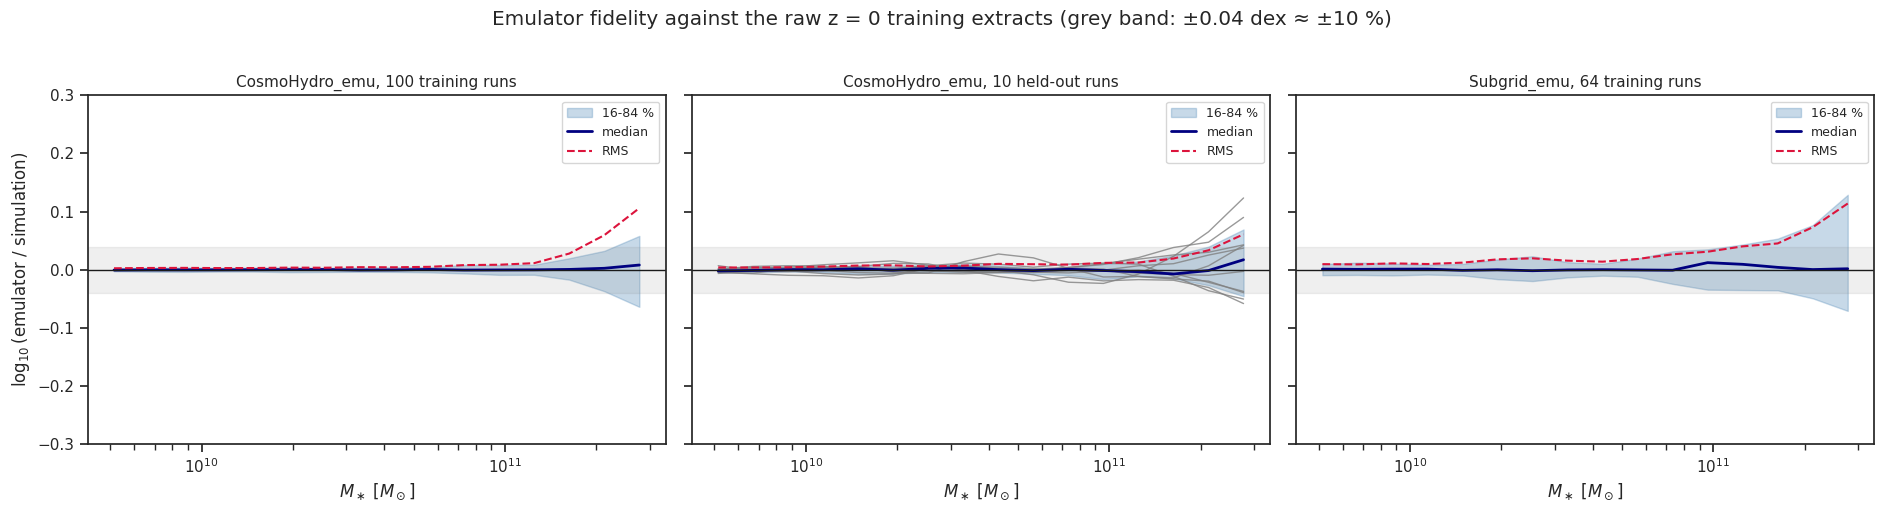

 M* [Msun]   CosmoHydro_emu   CosmoHydro_emu   Subgrid_emu, 6
  5.15e+09    0.003 (rms)    0.004 (rms)    0.010 (rms)
  6.71e+09    0.003 (rms)    0.004 (rms)    0.009 (rms)
  8.76e+09    0.003 (rms)    0.004 (rms)    0.011 (rms)
  1.14e+10    0.003 (rms)    0.005 (rms)    0.010 (rms)
  1.49e+10    0.003 (rms)    0.007 (rms)    0.012 (rms)
  1.94e+10    0.004 (rms)    0.008 (rms)    0.018 (rms)
  2.53e+10    0.004 (rms)    0.006 (rms)    0.020 (rms)
  3.31e+10    0.005 (rms)    0.007 (rms)    0.016 (rms)
  4.31e+10    0.004 (rms)    0.010 (rms)    0.014 (rms)
  5.62e+10    0.005 (rms)    0.010 (rms)    0.019 (rms)
  7.33e+10    0.008 (rms)    0.009 (rms)    0.027 (rms)
  9.57e+10    0.009 (rms)    0.012 (rms)    0.031 (rms)
  1.25e+11    0.011 (rms)    0.012 (rms)    0.040 (rms)
  1.63e+11    0.028 (rms)    0.019 (rms)    0.045 (rms)
  2.12e+11    0.060 (rms)    0.034 (rms)    0.073 (rms)
  2.77e+11    0.106 (rms)    0.061 (rms)    0.114 (rms)


In [10]:
rows = lambda fn, P: np.array([fn(q)[0] for q in P])        # per-row predictions (batch path differs per package)
pred_ch_tr = rows(lambda q: ch.predict(q, z=0.0), design[:100])
pred_ch_te = rows(lambda q: ch.predict(q, z=0.0), design[100:])
pred_sg_tr = rows(sg.predict, P_sg)
res = {'CosmoHydro_emu, 100 training runs': L10(pred_ch_tr) - L10(raw_ch[:100]),
       'CosmoHydro_emu, 10 held-out runs': L10(pred_ch_te) - L10(raw_ch[100:]),
       'Subgrid_emu, 64 training runs': L10(pred_sg_tr) - L10(raw_sg)}

fig, axes = plt.subplots(1, 3, figsize=(19, 5), sharey=True)
for ax, (name, r) in zip(axes, res.items()):
    lo, med, hi = np.nanpercentile(r, [16, 50, 84], axis=0)
    if r.shape[0] <= 10:
        for row in r: ax.plot(x, row, color='gray', lw=1, alpha=0.8)
    ax.fill_between(x, lo, hi, color='steelblue', alpha=0.3, label='16-84 %')
    ax.plot(x, med, color='navy', lw=2, label='median')
    ax.plot(x, np.sqrt(np.nanmean(r**2, axis=0)), color='crimson', lw=1.5, ls='--', label='RMS')
    ax.axhline(0, color='k', lw=1); ax.axhspan(-0.04, 0.04, color='gray', alpha=0.12)
    ax.set_xscale('log'); ax.set_title(name, fontsize=11); ax.set_xlabel(r'$M_\ast\;[M_\odot]$')
    ax.legend(fontsize=9)
axes[0].set_ylabel(r'$\log_{10}$(emulator / simulation)'); axes[0].set_ylim(-0.3, 0.3)
plt.suptitle('Emulator fidelity against the raw z = 0 training extracts (grey band: ±0.04 dex ≈ ±10 %)', y=1.02)
plt.tight_layout(); plt.show()

print(f"{'M* [Msun]':>10s} " + ' '.join(f'{k[:14]:>16s}' for k in res))
for j, xi in enumerate(x):
    print(f'{xi:10.2e} ' + ' '.join(f"{np.sqrt(np.nanmean(r[:, j]**2)):8.3f} (rms)" for r in res.values()))

### F2. Are the two simulation suites consistent with each other?

Cross-prediction: each emulator is evaluated at the *other* suite's design points and
compared with that suite's raw simulations.

- **Subgrid_emu → 400 h⁻¹Mpc runs**: the subgrid emulator has no cosmology axis, so the
  residual includes the (small, ≤ 0.04 dex, section C) cosmology effect; runs with
  M_seed > 1.2×10⁶ M☉ are outside its box and skipped.
- **CosmoHydro_emu → 128 h⁻¹Mpc runs**: evaluated at the fiducial cosmology, which *is*
  the cosmology of the 128 h⁻¹Mpc suite, so this residual should be pure emulator +
  sample-variance noise if the suites agree.

If the 400 h⁻¹Mpc simulations themselves have more massive galaxies than the
128 h⁻¹Mpc ones at the same parameters, the first panel will sit above zero at high mass
while F1 shows the emulator is fine. The lower panels test whether the residual at the
top mass bin correlates with cosmology.

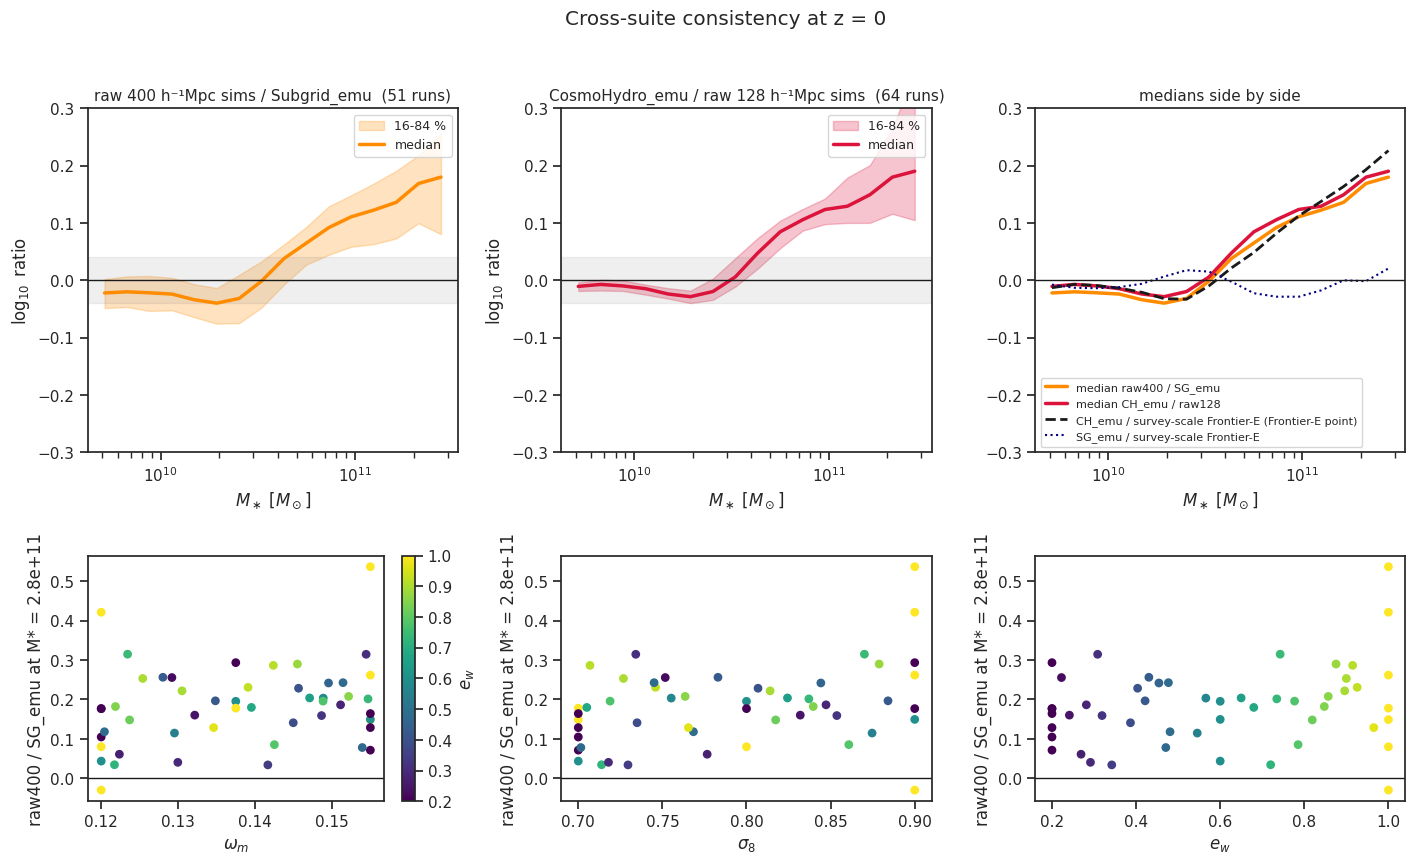

median log10(raw400 / SG_emu) at 1e10, 1e11, 2.8e11: [-0.022  0.111  0.18 ]
median log10(CH_emu / raw128)  at 1e10, 1e11, 2.8e11: [-0.01   0.123  0.19 ]
corr(raw400/SG_emu at top bin, omega_m) = +0.24
corr(raw400/SG_emu at top bin, sigma_8) = +0.35


In [11]:
inbox = design[:, 2] <= 1.2
pred_sg_at_ch = rows(sg.predict, design[inbox, :5])
r_a = L10(raw_ch[inbox]) - L10(pred_sg_at_ch)             # raw 400-suite sims / Subgrid_emu
pred_ch_at_sg = rows(lambda q: ch.predict(q, z=0.0), np.hstack([P_sg, np.tile(P_COSMO, (len(P_sg), 1))]))
r_b = L10(pred_ch_at_sg) - L10(raw_sg)                     # CosmoHydro_emu / raw 128-suite sims

fig = plt.figure(figsize=(17, 9)); gs = fig.add_gridspec(2, 3, height_ratios=[1.4, 1], hspace=0.35, wspace=0.28)
for j, (r, name, c) in enumerate([(r_a, f'raw 400 h⁻¹Mpc sims / Subgrid_emu  ({inbox.sum()} runs)', 'darkorange'),
                                  (r_b, 'CosmoHydro_emu / raw 128 h⁻¹Mpc sims  (64 runs)', 'crimson')]):
    ax = fig.add_subplot(gs[0, j])
    lo, med, hi = np.nanpercentile(r, [16, 50, 84], axis=0)
    ax.fill_between(x, lo, hi, color=c, alpha=0.25, label='16-84 %'); ax.plot(x, med, color=c, lw=2.5, label='median')
    ax.axhline(0, color='k', lw=1); ax.axhspan(-0.04, 0.04, color='gray', alpha=0.12)
    ax.set_xscale('log'); ax.set_ylim(-0.3, 0.3); ax.set_title(name, fontsize=11)
    ax.set_xlabel(r'$M_\ast\;[M_\odot]$'); ax.set_ylabel(r'$\log_{10}$ ratio'); ax.legend(fontsize=9)
ax = fig.add_subplot(gs[0, 2])
ax.plot(x, np.nanmedian(r_a, axis=0), color='darkorange', lw=2.5, label='median raw400 / SG_emu')
ax.plot(x, np.nanmedian(r_b, axis=0), color='crimson', lw=2.5, label='median CH_emu / raw128')
ax.plot(x, L10(ch_m) - L10(phi_ref), color='k', lw=2, ls='--', label=f'CH_emu / {ref_name} (Frontier-E point)')
ax.plot(x, L10(sg_m) - L10(phi_ref), color='navy', lw=1.5, ls=':', label=f'SG_emu / {ref_name}')
ax.axhline(0, color='k', lw=1); ax.set_xscale('log'); ax.set_ylim(-0.3, 0.3); ax.legend(fontsize=8)
ax.set_title('medians side by side', fontsize=11); ax.set_xlabel(r'$M_\ast\;[M_\odot]$')
# does the 400-suite residual at the top bin depend on cosmology?
jt = -1
for j, (col, lab) in enumerate([(5, r'$\omega_m$'), (6, r'$\sigma_8$'), (1, r'$e_w$')]):
    ax = fig.add_subplot(gs[1, j])
    sc = ax.scatter(design[inbox, col], r_a[:, jt], c=design[inbox, 1], cmap='viridis', s=28)
    ax.axhline(0, color='k', lw=1); ax.set_xlabel(lab); ax.set_ylabel(f'raw400 / SG_emu at M* = {x[jt]:.1e}')
    if j == 0: plt.colorbar(sc, ax=ax, label=r'$e_w$')
plt.suptitle('Cross-suite consistency at z = 0', y=0.99); plt.show()

print('median log10(raw400 / SG_emu) at 1e10, 1e11, 2.8e11:', np.round(np.nanmedian(r_a, axis=0)[[i10, i11, -1]], 3))
print('median log10(CH_emu / raw128)  at 1e10, 1e11, 2.8e11:', np.round(np.nanmedian(r_b, axis=0)[[i10, i11, -1]], 3))
for col, lab in [(5, 'omega_m'), (6, 'sigma_8')]:
    cc = np.corrcoef(design[inbox, col], np.nan_to_num(r_a[:, jt]))[0, 1]
    print(f'corr(raw400/SG_emu at top bin, {lab}) = {cc:+.2f}')

### F3. Emulator-free check: quadratic response surfaces fitted to each suite, evaluated at Frontier-E

A ridge-regularised quadratic in the (normalised) parameters is fitted per mass bin to
log₁₀φ of each suite (7 parameters for the 400 h⁻¹Mpc data, 5 for the 128 h⁻¹Mpc data),
with leave-one-out RMS quoted for quality. Evaluated at the Frontier-E parameters this
says what each *dataset* implies there, independently of the GP emulators.
Also shown: the raw GSMFs of the nearest design points of each suite (distance in the
normalised subgrid parameters; the 400 h⁻¹Mpc distance also includes the cosmology).

leave-one-out RMS of the quadratic fits [dex], per bin:
  400 suite: [0.009 0.013 0.017 0.019 0.021 0.024 0.028 0.029 0.03  0.034 0.034 0.038
 0.043 0.05  0.061 0.078]
  128 suite: [0.009 0.011 0.013 0.015 0.015 0.014 0.01  0.015 0.021 0.024 0.027 0.031
 0.039 0.04  0.064 0.062]

nearest 128-suite runs (normalised distance, params, log10 raw/ref at 1e11 and 2.8e11):
  d=0.34  [2.857 0.314 0.8   0.327 0.32 ]  +0.041 +0.056
  d=0.37  [3.524 0.454 0.771 0.24  0.057]  -0.025 +0.079
  d=0.42  [3.27  0.238 0.695 0.676 0.151]  +0.101 +0.148
nearest 400-suite runs:
  d=0.56  RUN073 [2.978 0.65  1.059 0.397 0.389 0.147 0.824]  -0.005 +0.057
  d=0.61  RUN092 [3.839 0.454 0.827 0.154 0.193 0.15  0.844]  +0.014 +0.170
  d=0.65  RUN059 [3.182 0.319 0.638 0.81  0.548 0.149 0.854]  +0.210 +0.302


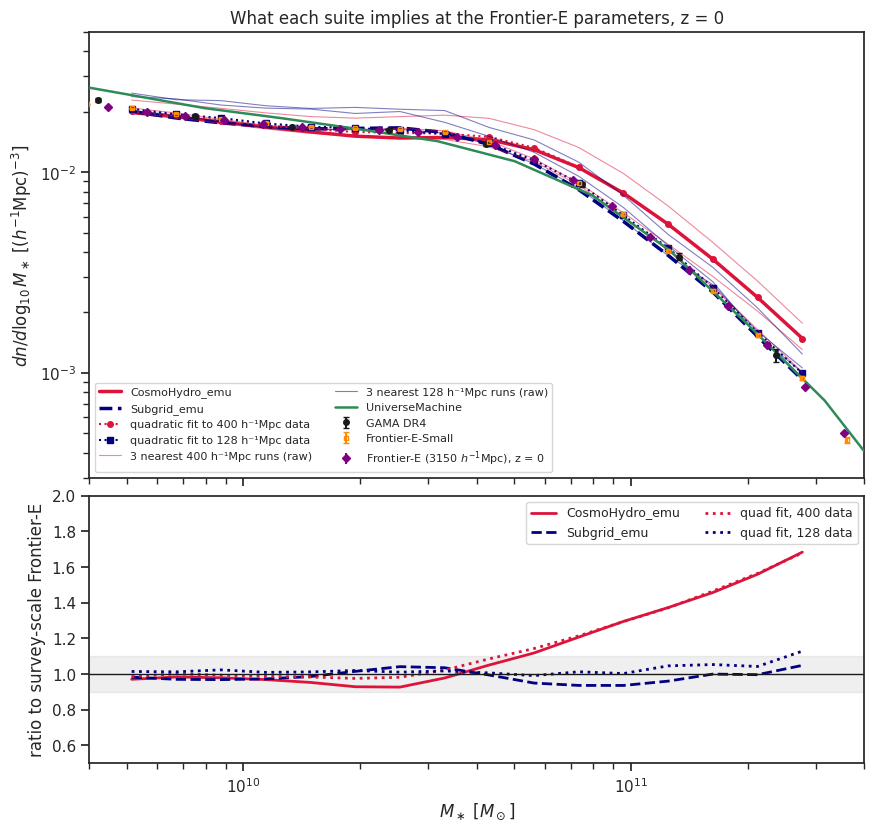


ratio to survey-scale Frontier-E at 1e11 / 2.8e11 Msun:
  CosmoHydro_emu       1.295  1.683
  Subgrid_emu          0.936  1.049
  quad fit 400 data    1.294  1.679
  quad fit 128 data    1.003  1.128


In [12]:
def quad_features(P):
    n, d = P.shape
    cols = [np.ones(n)] + [P[:, i] for i in range(d)] + [P[:, i] * P[:, j] for i in range(d) for j in range(i, d)]
    return np.column_stack(cols)

def quad_fit(P, Y, p0, lam=1e-2):
    # per-bin ridge quadratic; returns prediction at p0 and leave-one-out RMS per bin
    lo, hi = P.min(0), P.max(0); A = quad_features((P - lo) / (hi - lo)); a0 = quad_features(((p0 - lo) / (hi - lo))[None, :])
    pred, loo = np.zeros(Y.shape[1]), np.zeros(Y.shape[1])
    for j in range(Y.shape[1]):
        ok = np.isfinite(Y[:, j]); Aj, yj = A[ok], Y[ok, j]
        coef = np.linalg.solve(Aj.T @ Aj + lam * np.eye(A.shape[1]), Aj.T @ yj)
        pred[j] = (a0 @ coef)[0]
        H = Aj @ np.linalg.solve(Aj.T @ Aj + lam * np.eye(A.shape[1]), Aj.T)
        loo[j] = np.sqrt(np.mean(((yj - Aj @ coef) / (1 - np.diag(H)))**2))
    return pred, loo

q_ch, loo_ch = quad_fit(design, L10(raw_ch), np.array(P7))
q_sg, loo_sg = quad_fit(P_sg, L10(raw_sg), np.array(P5))
print('leave-one-out RMS of the quadratic fits [dex], per bin:')
print('  400 suite:', np.round(loo_ch, 3)); print('  128 suite:', np.round(loo_sg, 3))

# nearest design points
box_lo, box_hi = np.array([2, 0.2, 0.6, 0.1, 0.02]), np.array([4, 1, 1.2, 1.2, 1.2])
d_sg = np.sqrt((((P_sg - P5) / (box_hi - box_lo))**2).sum(1))
d_ch = np.sqrt((((design[:, :5] - P5) / (box_hi - box_lo))**2).sum(1)
               + (((design[:, 5:] - P_COSMO) / np.array([0.035, 0.2]))**2).sum(1))
nn_sg, nn_ch = np.argsort(d_sg)[:3], np.argsort(d_ch)[:3]
print('\nnearest 128-suite runs (normalised distance, params, log10 raw/ref at 1e11 and 2.8e11):')
for i in nn_sg: print(f'  d={d_sg[i]:.2f}  {np.round(P_sg[i], 3)}  {L10(raw_sg[i])[i11] - L10(phi_ref)[i11]:+.3f} {L10(raw_sg[i])[-1] - L10(phi_ref)[-1]:+.3f}')
print('nearest 400-suite runs:')
for i in nn_ch: print(f'  d={d_ch[i]:.2f}  RUN{i:03d} {np.round(design[i], 3)}  {L10(raw_ch[i])[i11] - L10(phi_ref)[i11]:+.3f} {L10(raw_ch[i])[-1] - L10(phi_ref)[-1]:+.3f}')

fig, (ax, axr) = plt.subplots(2, 1, figsize=(10, 9.5), sharex=True, gridspec_kw={'height_ratios': [2, 1.2], 'hspace': 0.05})
ax.plot(x, ch_m, color='crimson', lw=2.5, label='CosmoHydro_emu')
ax.plot(x, sg_m, color='navy', lw=2.5, ls='--', label='Subgrid_emu')
ax.plot(x, 10**q_ch, color='crimson', lw=1.5, ls=':', marker='o', ms=4, label='quadratic fit to 400 h⁻¹Mpc data')
ax.plot(x, 10**q_sg, color='navy', lw=1.5, ls=':', marker='s', ms=4, label='quadratic fit to 128 h⁻¹Mpc data')
for i in nn_ch: ax.plot(x, raw_ch[i], color='crimson', lw=0.8, alpha=0.5)
for i in nn_sg: ax.plot(x, raw_sg[i], color='navy', lw=0.8, alpha=0.5)
ax.plot([], [], color='crimson', lw=0.8, alpha=0.5, label='3 nearest 400 h⁻¹Mpc runs (raw)')
ax.plot([], [], color='navy', lw=0.8, alpha=0.5, label='3 nearest 128 h⁻¹Mpc runs (raw)')
draw_targets(ax, legend=True)
if fe_survey is not None:
    ax.errorbar(fe_survey['x'], fe_survey['y'], yerr=fe_survey['yerr'], fmt='D', ms=4, color='purple', label=fe_survey['label'], zorder=6)
ax.set_xscale('log'); ax.set_yscale('log'); ax.set_xlim(4e9, 4e11); ax.set_ylim(3e-4, 5e-2)
ax.set_ylabel(r'$dn/d\log_{10}M_\ast\;[(h^{-1}{\rm Mpc})^{-3}]$'); ax.legend(fontsize=8, ncol=2, loc='lower left')
ax.set_title('What each suite implies at the Frontier-E parameters, z = 0')
for yv, c, ls, lab in [(ch_m, 'crimson', '-', 'CosmoHydro_emu'), (sg_m, 'navy', '--', 'Subgrid_emu'),
                       (10**q_ch, 'crimson', ':', 'quad fit, 400 data'), (10**q_sg, 'navy', ':', 'quad fit, 128 data')]:
    axr.plot(x, yv / phi_ref, color=c, lw=2, ls=ls, label=lab)
axr.axhline(1, color='k', lw=1); axr.axhspan(0.9, 1.1, color='gray', alpha=0.12)
axr.set_xscale('log'); axr.set_ylim(0.5, 2.0); axr.set_xlabel(r'$M_\ast\;[M_\odot]$'); axr.set_ylabel(f'ratio to {ref_name}')
axr.legend(fontsize=9, ncol=2); plt.show()

print(f'\nratio to {ref_name} at 1e11 / 2.8e11 Msun:')
for lab, yv in [('CosmoHydro_emu', ch_m), ('Subgrid_emu', sg_m), ('quad fit 400 data', 10**q_ch), ('quad fit 128 data', 10**q_sg)]:
    print(f'  {lab:20s} {yv[i11] / phi_ref[i11]:.3f}  {yv[-1] / phi_ref[-1]:.3f}')

### F4. The two ensembles side by side at fixed e_w

e_w is the dominant subgrid driver of the GSMF (section B). Plotting φ at two masses
against e_w for every run of both suites (colour = κ_w, the second driver at high mass)
shows directly whether the 400 h⁻¹Mpc simulations produce more massive galaxies than
the 128 h⁻¹Mpc ones at the same feedback parameters.

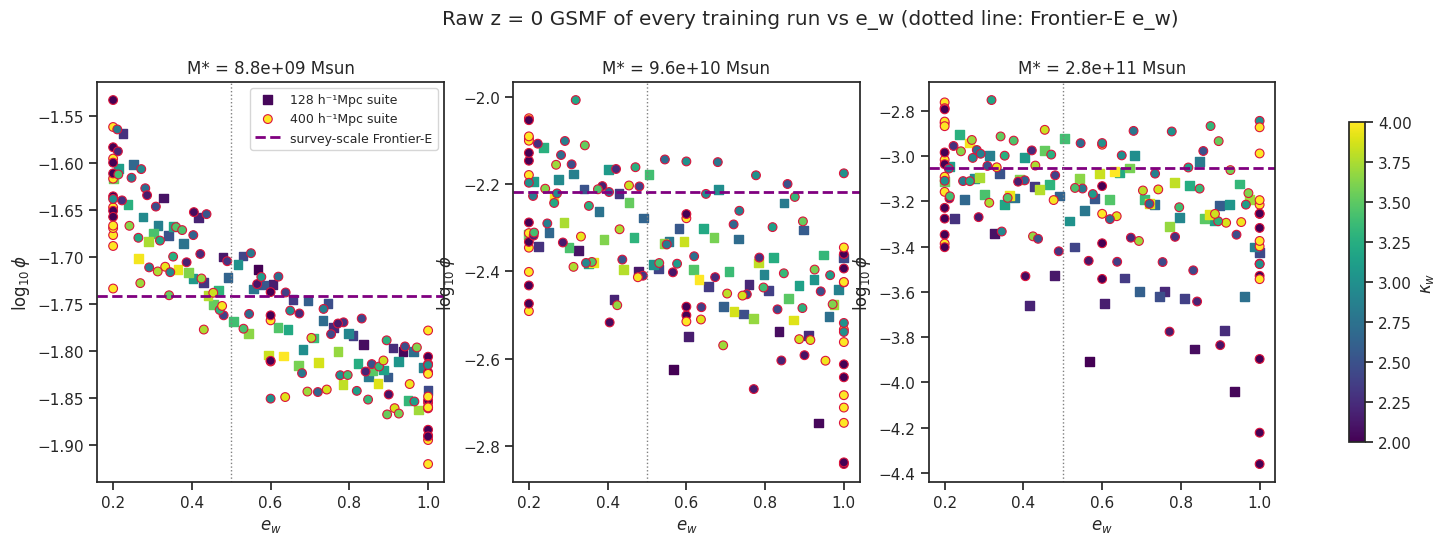

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(19, 5.2))
for ax, j in zip(axes, [i10, i11, len(x) - 1]):
    s1 = ax.scatter(P_sg[:, 1], L10(raw_sg[:, j]), c=P_sg[:, 0], cmap='viridis', vmin=2, vmax=4, marker='s', s=40, label='128 h⁻¹Mpc suite')
    ax.scatter(design[:, 1], L10(raw_ch[:, j]), c=design[:, 0], cmap='viridis', vmin=2, vmax=4, marker='o', s=40, edgecolor='crimson', lw=0.8, label='400 h⁻¹Mpc suite')
    ax.axhline(L10(phi_ref)[j], color='purple', lw=2, ls='--', label=ref_name)
    ax.axvline(P5[1], color='gray', lw=1, ls=':')
    ax.set_xlabel(r'$e_w$'); ax.set_title(f'M* = {x[j]:.1e} Msun'); ax.set_ylabel(r'$\log_{10}\phi$')
    if j == i10: ax.legend(fontsize=9)
plt.colorbar(s1, ax=axes, label=r'$\kappa_w$', shrink=0.8)
plt.suptitle('Raw z = 0 GSMF of every training run vs e_w (dotted line: Frontier-E e_w)', y=1.02); plt.show()

### F5. Is it a halo-level (gravity / resolution) difference or a galaxy-level one?

The HAVOCC `HaloMassFunction_624.txt` extracts carry, next to the measured SOD mass
function, a Tinker+08 prediction evaluated for each run's *own* cosmology. The ratio
HMF_SOD / Tinker therefore compares the suites at the halo level with the cosmology
divided out. If the 400 h⁻¹Mpc runs sit above the 128 h⁻¹Mpc runs and Frontier-E-Small
here too, the excess of massive galaxies is inherited from the haloes (resolution,
softening, code version, cosmology-parameter mapping); if the HMF ratios agree, the
difference is in the galaxy modelling / galaxy finding. The CosmoHydro HMF emulator at the
Frontier-E point is also compared directly with the Frontier-E-Small HMF.

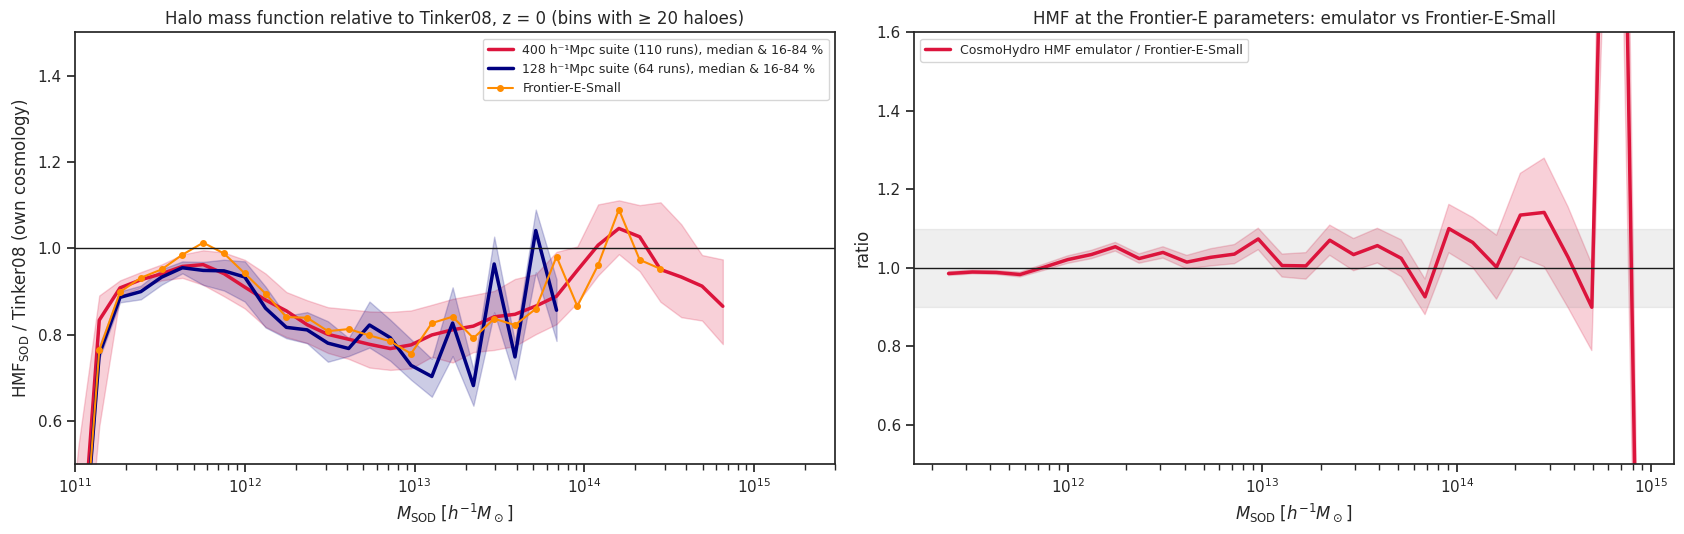

median HMF_SOD/Tinker over 1e12-1e14 Msun/h:  400 suite 0.821   128 suite 0.811   Frontier-E-Small 0.832
CH HMF emulator / Frontier-E-Small at ['2e+11: 0.986', '8e+11: 1.001', '2e+12: 1.024', '7e+12: 1.035', '2e+13: 1.070', '7e+13: 0.926', '2e+14: 1.135', '7e+14: 3.446']


In [14]:
def read_hmf(f):
    d = np.loadtxt(f); return d[:, 0], d[:, 1], d[:, 3], d[:, 4]          # M [Msun/h], HMF_SOD, counts, Tinker08

hmf_ch = [read_hmf(f'{CH_DIR}/RUN{i:03d}/extract/HaloMassFunction_624.txt') for i in range(110)]
hmf_sg = [read_hmf(f'{SG_DIR}/{d}/analysis_pipeline/extract/HaloMassFunction_624.txt') for d in dirs]
mh, fes_hmf, fes_cnt, fes_tink = read_hmf('../../Data/ProfileData/SCIDAC_RUNS/SMALL_FRONTIERE/extract_14.6/HaloMassFunction_624.txt')
assert all(np.allclose(h[0], mh) for h in hmf_ch + hmf_sg)
ratio = lambda hm: np.array([np.where((h[2] >= 20) & (h[3] > 0), h[1] / h[3], np.nan) for h in hm])   # >= 20 haloes per bin
R_ch, R_sg = ratio(hmf_ch), ratio(hmf_sg)
R_fes = np.where((fes_cnt >= 20) & (fes_tink > 0), fes_hmf / fes_tink, np.nan)

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(17, 5.5))
for R, c, lab in [(R_ch, 'crimson', '400 h⁻¹Mpc suite (110 runs)'), (R_sg, 'navy', '128 h⁻¹Mpc suite (64 runs)')]:
    lo, med, hi = np.nanpercentile(R, [16, 50, 84], axis=0)
    ax.fill_between(mh, lo, hi, color=c, alpha=0.2); ax.plot(mh, med, color=c, lw=2.5, label=lab + ', median & 16-84 %')
ax.plot(mh, R_fes, 'o-', color='darkorange', ms=4, lw=1.5, label='Frontier-E-Small')
ax.axhline(1, color='k', lw=1); ax.set_xscale('log'); ax.set_ylim(0.5, 1.5); ax.set_xlim(1e11, 3e15)
ax.set_xlabel(r'$M_{\rm SOD}\;[h^{-1}M_\odot]$'); ax.set_ylabel('HMF$_{\\rm SOD}$ / Tinker08 (own cosmology)')
ax.set_title('Halo mass function relative to Tinker08, z = 0 (bins with ≥ 20 haloes)'); ax.legend(fontsize=9)

# CosmoHydro HMF emulator at the Frontier-E point vs Frontier-E-Small
hmf_emu = ce.load_emulator('HMF'); xh = np.asarray(ce.get_x_grid('HMF')[0])
hm_m, hm_s = hmf_emu.predict(P7, z=0.0)
ok = fes_hmf > 0
fes_i = 10**np.interp(np.log10(xh), np.log10(mh[ok]), np.log10(fes_hmf[ok]))
ax2.plot(xh, hm_m / fes_i, color='crimson', lw=2.5, label='CosmoHydro HMF emulator / Frontier-E-Small')
ax2.fill_between(xh, (hm_m - 2*hm_s) / fes_i, (hm_m + 2*hm_s) / fes_i, color='crimson', alpha=0.2)
ax2.axhline(1, color='k', lw=1); ax2.axhspan(0.9, 1.1, color='gray', alpha=0.12)
ax2.set_xscale('log'); ax2.set_ylim(0.5, 1.6); ax2.set_xlabel(r'$M_{\rm SOD}\;[h^{-1}M_\odot]$'); ax2.set_ylabel('ratio')
ax2.set_title('HMF at the Frontier-E parameters: emulator vs Frontier-E-Small'); ax2.legend(fontsize=9)
plt.tight_layout(); plt.show()

sel = (mh > 1e12) & (mh < 1e14)
print('median HMF_SOD/Tinker over 1e12-1e14 Msun/h:  400 suite %.3f   128 suite %.3f   Frontier-E-Small %.3f'
      % (np.nanmedian(np.nanmedian(R_ch, 0)[sel]), np.nanmedian(np.nanmedian(R_sg, 0)[sel]), np.nanmedian(R_fes[sel])))
print('CH HMF emulator / Frontier-E-Small at', [f'{m:.0e}: {r:.3f}' for m, r in zip(xh[::4], (hm_m / fes_i)[::4])])

## G. What could make the 400 h⁻¹Mpc training GSMFs high? Four discriminating tests

Candidate causes, and what each predicts:

| cause | signature |
|---|---|
| **mass-axis convention** (M☉/h vs M☉, i.e. a 0.17 dex shift; or a different aperture) | a *horizontal* shift of the whole GSMF: the log-ratio should equal −Δ × (local slope), so the implied shift Δ(M) is constant in mass and **the same at every redshift** |
| **weaker late-time quenching / stronger star formation** (AGN or wind parameters mapped differently, code version) | excess confined to the massive end and **growing towards z = 0**; more total star formation (CSFR) or different cluster gas fractions |
| **galaxy finder / stellar-mass assignment** (more mass per galaxy at the same star formation) | GSMF-integrated stellar mass higher at the *same* integrated CSFR; HMF unaffected (already shown in F5) |

Both suites' HAVOCC configs use h = 0.6766 for the M☉ conversion (checked in the
400-suite `config.toml`; the 128-suite extracts share the identical bin grid and header),
so a bare h slip is unlikely, but test G1 quantifies any *effective* rescaling regardless
of its origin.

### G1. Is the excess a horizontal mass shift?

If galaxy masses in the 400 h⁻¹Mpc suite were simply rescaled by 10^Δ, then
log₁₀φ₄₀₀(M) − log₁₀φ_ref(M) = −Δ · d log φ_ref / d log M. The implied Δ(M) is plotted for
the CosmoHydro_emu / survey-scale Frontier-E excess and for the median raw-400 / Subgrid_emu
residual; a single best-fit Δ is also applied to the reference GSMF to see how much of the
curve it explains.

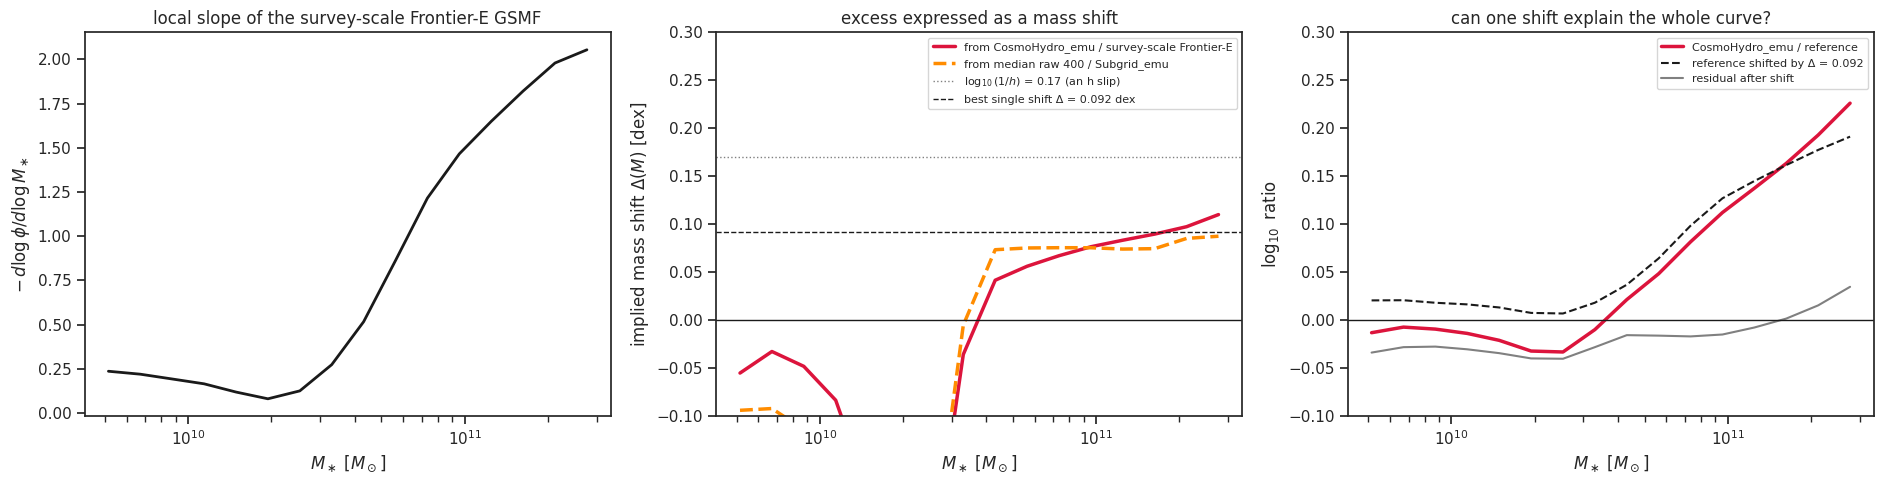

implied mass shift Δ [dex] at 1e10 / 3e10 / 1e11 / 2.8e11 Msun:
  CosmoHydro_emu vs reference : [-0.048 -0.036  0.077  0.11 ]
  raw 400 vs Subgrid_emu      : [-0.114 -0.005  0.076  0.088]
best single shift Δ = 0.092 dex (x1.24 in mass); residual RMS after shift = 0.027 dex (before: 0.100); residual in the 4 lowest / 4 highest bins: [-0.034 -0.028 -0.027 -0.03 ] / [-0.008  0.002  0.016  0.035]


In [15]:
lx = np.log10(x)
ref_ok = fe_survey if fe_survey is not None else fes
tx_r, ty_r, _, _ = _prep(ref_ok); lref = np.log10(tx_r); lphi_ref = np.log10(ty_r)
slope = np.gradient(np.interp(lx, lref, lphi_ref), lx)           # d log phi / d log M of the reference
r_fe = L10(ch_m) - L10(phi_ref)
r_400 = np.nanmedian(r_a, axis=0)
D_fe, D_400 = r_fe / (-slope), r_400 / (-slope)

def shifted_ref(Delta):                                          # phi_ref evaluated at M / 10^Delta
    return np.interp(lx - Delta, lref, lphi_ref)
grid = np.linspace(-0.05, 0.3, 701)
cost = [np.nansum((L10(ch_m) - shifted_ref(D))**2) for D in grid]
D_best = grid[int(np.argmin(cost))]
resid_shift = L10(ch_m) - shifted_ref(D_best)

fig, axes = plt.subplots(1, 3, figsize=(19, 5))
axes[0].plot(x, -slope, 'k-', lw=2); axes[0].set_xscale('log'); axes[0].set_xlabel(r'$M_\ast\;[M_\odot]$')
axes[0].set_ylabel(r'$-\,d\log\phi/d\log M_\ast$'); axes[0].set_title(f'local slope of the {ref_name} GSMF')
axes[1].plot(x, D_fe, color='crimson', lw=2.5, label=f'from CosmoHydro_emu / {ref_name}')
axes[1].plot(x, D_400, color='darkorange', lw=2.5, ls='--', label='from median raw 400 / Subgrid_emu')
axes[1].axhline(np.log10(1 / h), color='gray', lw=1, ls=':', label=r'$\log_{10}(1/h)$ = 0.17 (an h slip)')
axes[1].axhline(D_best, color='k', lw=1, ls='--', label=f'best single shift Δ = {D_best:.3f} dex')
axes[1].axhline(0, color='k', lw=1); axes[1].set_xscale('log'); axes[1].set_ylim(-0.1, 0.3)
axes[1].set_xlabel(r'$M_\ast\;[M_\odot]$'); axes[1].set_ylabel(r'implied mass shift $\Delta(M)$ [dex]')
axes[1].set_title('excess expressed as a mass shift'); axes[1].legend(fontsize=8)
axes[2].plot(x, r_fe, color='crimson', lw=2.5, label='CosmoHydro_emu / reference')
axes[2].plot(x, shifted_ref(D_best) - L10(phi_ref), color='k', lw=1.5, ls='--', label=f'reference shifted by Δ = {D_best:.3f}')
axes[2].plot(x, resid_shift, color='gray', lw=1.5, label='residual after shift')
axes[2].axhline(0, color='k', lw=1); axes[2].set_xscale('log'); axes[2].set_ylim(-0.1, 0.3)
axes[2].set_xlabel(r'$M_\ast\;[M_\odot]$'); axes[2].set_ylabel(r'$\log_{10}$ ratio'); axes[2].legend(fontsize=8)
axes[2].set_title('can one shift explain the whole curve?')
plt.tight_layout(); plt.show()

print('implied mass shift Δ [dex] at 1e10 / 3e10 / 1e11 / 2.8e11 Msun:')
print('  CosmoHydro_emu vs reference :', np.round(D_fe[[i10, np.argmin(np.abs(lx - 10.5)), i11, -1]], 3))
print('  raw 400 vs Subgrid_emu      :', np.round(D_400[[i10, np.argmin(np.abs(lx - 10.5)), i11, -1]], 3))
print(f'best single shift Δ = {D_best:.3f} dex (x{10**D_best:.2f} in mass); residual RMS after shift = {np.sqrt(np.nanmean(resid_shift**2)):.3f} dex '
      f'(before: {np.sqrt(np.nanmean(r_fe**2)):.3f}); residual in the 4 lowest / 4 highest bins: '
      f'{np.round(resid_shift[:4], 3)} / {np.round(resid_shift[-4:], 3)}')

### G2. Redshift dependence of the suite difference

Both suites have GSMF extracts at steps 624/567/415/310/205 (z = 0, 0.1, 0.5, 1, 2), which
are CosmoHydro training snapshots. The CosmoHydro emulator is evaluated at the 64 subgrid
design points (fiducial cosmology) and at Frontier-E-Small's parameters, at each of these
redshifts, against the raw 128 h⁻¹Mpc and Frontier-E-Small extracts. A convention error is
redshift-independent; a physics difference that builds up at late times is not.

    z  CH_emu/raw128 @1e11   @2.8e11  CH_emu/FE-Small @1e11   @2.8e11   (median log10 ratios)


  0.0                0.123     0.190                  0.104     0.199


  0.1                0.116     0.201                  0.093     0.210


  0.5                0.079     0.208                  0.052     0.209


  1.0                0.033     0.224                  0.039     0.213


  2.0                0.027     0.065                  0.044     0.004


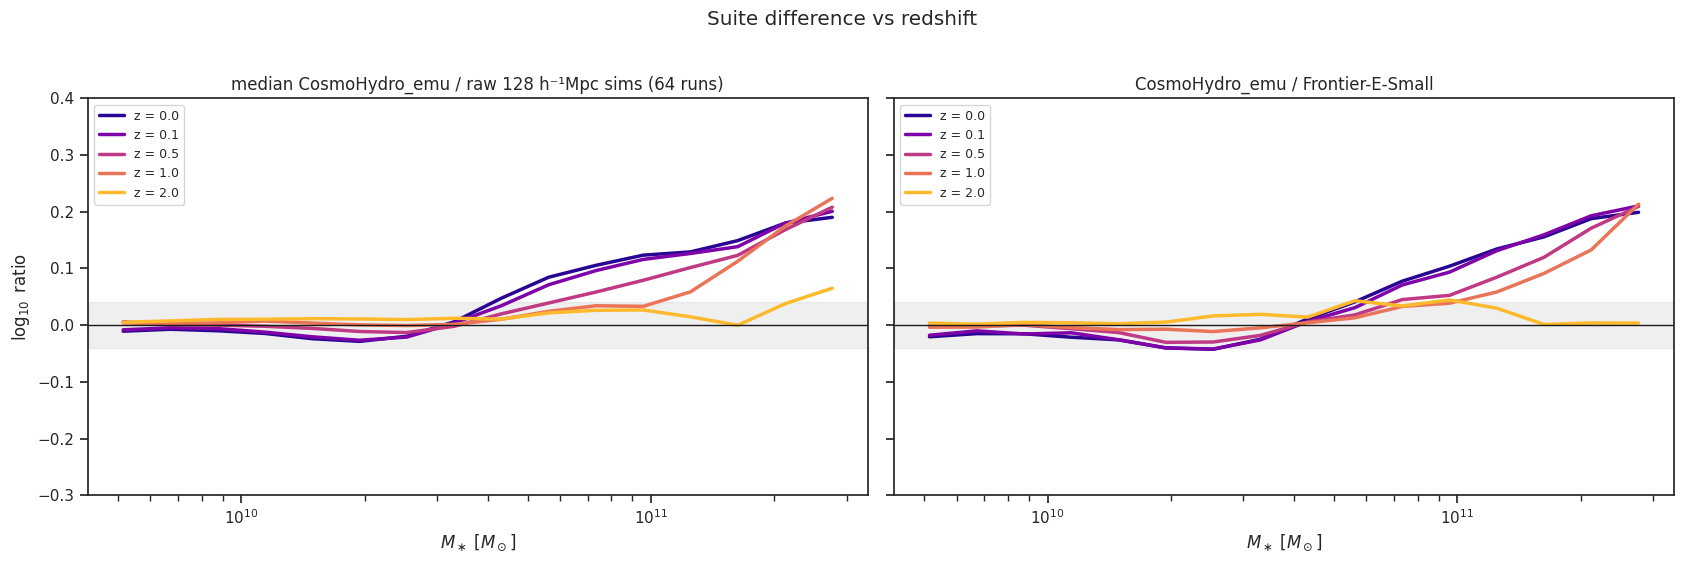

In [16]:
STEPS = {624: 0.0, 567: 0.0998, 415: 0.4987, 310: 0.9996, 205: 2.0036}
FES_DIR = '../../Data/ProfileData/SCIDAC_RUNS/SMALL_FRONTIERE/extract_14.6'
zc = plt.cm.plasma(np.linspace(0.05, 0.85, len(STEPS)))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(17, 5.5), sharey=True)
print(f"{'z':>5s} {'CH_emu/raw128 @1e11':>20s} {'@2.8e11':>9s} {'CH_emu/FE-Small @1e11':>22s} {'@2.8e11':>9s}   (median log10 ratios)")
for (step, z), c in zip(STEPS.items(), zc):
    raw128_z = np.array([read_extract(f'{SG_DIR}/{d}/analysis_pipeline/extract/GalStellarMassFunction_{step}.txt') for d in dirs])
    pred_z = rows(lambda q: ch.predict(q, z=min(z, 2.0))[0:1] if False else ch.predict(q, z=min(z, 2.0)), np.hstack([P_sg, np.tile(P_COSMO, (len(P_sg), 1))]))
    r_z = L10(pred_z) - L10(raw128_z)
    med = np.nanmedian(r_z, axis=0); nok = np.isfinite(r_z).sum(0)
    med[nok < 16] = np.nan                                             # need most boxes to be non-empty
    ax1.plot(x, med, color=c, lw=2.5, label=f'z = {z:.1f}')
    fes_z = read_extract(f'{FES_DIR}/GalStellarMassFunction_{step}.txt')
    m_fes, _ = ch.predict(P7, z=min(z, 2.0))
    r_fes = L10(m_fes) - L10(fes_z)
    ax2.plot(x, r_fes, color=c, lw=2.5, label=f'z = {z:.1f}')
    print(f'{z:5.1f} {med[i11]:20.3f} {med[-1]:9.3f} {r_fes[i11]:22.3f} {r_fes[-1]:9.3f}')
for ax, t in [(ax1, 'median CosmoHydro_emu / raw 128 h⁻¹Mpc sims (64 runs)'), (ax2, 'CosmoHydro_emu / Frontier-E-Small')]:
    ax.axhline(0, color='k', lw=1); ax.axhspan(-0.04, 0.04, color='gray', alpha=0.12)
    ax.set_xscale('log'); ax.set_xlabel(r'$M_\ast\;[M_\odot]$'); ax.set_title(t); ax.legend(fontsize=9)
ax1.set_ylabel(r'$\log_{10}$ ratio'); ax1.set_ylim(-0.3, 0.4)
plt.suptitle('Suite difference vs redshift', y=1.02); plt.tight_layout(); plt.show()

### G3. Star-formation budget: raw CSFR histories and the stellar mass locked in galaxies

`CSFR.txt` gives the cosmic star-formation-rate density of every run. Integrating it in
time gives the total stellar mass ever formed per volume (no mass return, same for all
runs); integrating M* φ(M*) over the full GSMF gives the stellar mass found *in galaxies*
at z = 0. If the 400 h⁻¹Mpc runs form more stars, the CSFR is higher; if they only
*assign* more of the same stars to galaxies (finder / aperture), the CSFR agrees but the
GSMF-integrated mass sits higher for the same integrated CSFR.

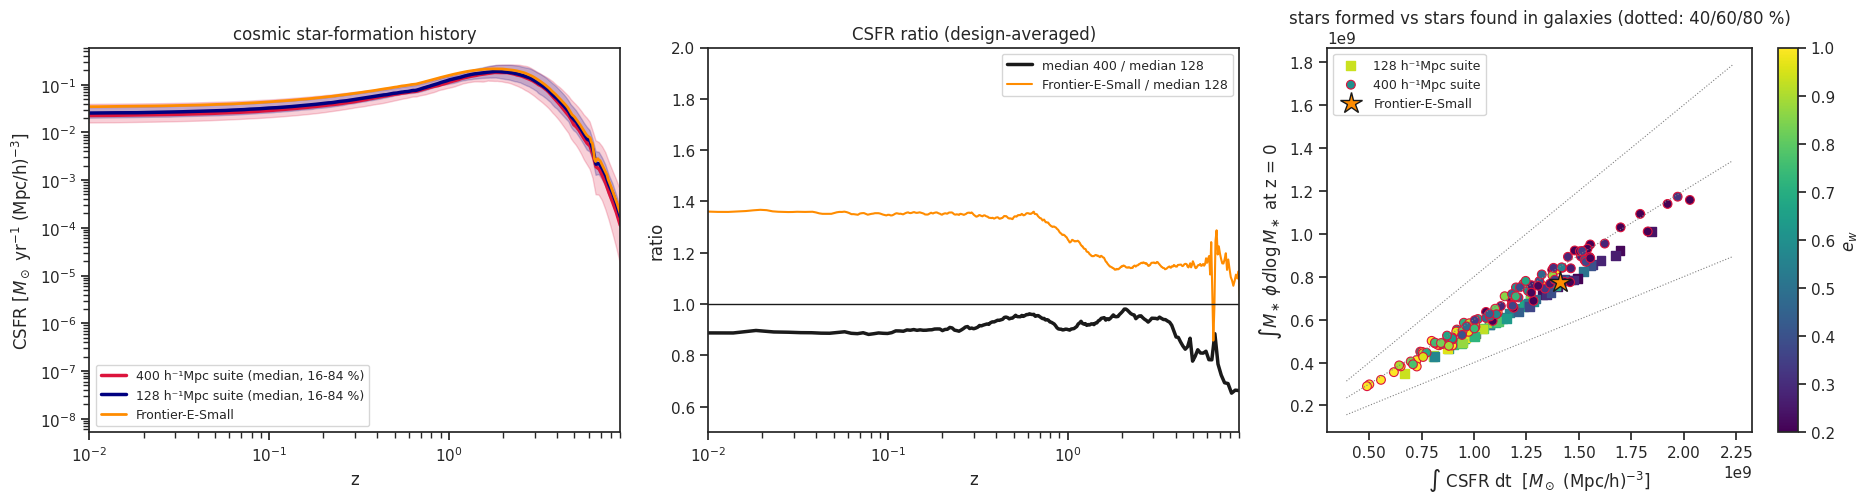

stellar mass in galaxies / stellar mass formed:  400 suite median 0.585 (16-84 %: 0.564-0.606)   128 suite median 0.535 (0.528-0.544)   Frontier-E-Small 0.549
median CSFR ratio 400/128 at z = 0, 0.5, 1, 2: 0.889, 0.951, 0.900, 0.965


In [17]:
H0_yr = FP['H0'] / 3.0857e19 * 3.15576e7                       # 1/yr
def rho_from_csfr(a, csfr, Om):
    ok = (a > 0) & np.isfinite(csfr); a, csfr = a[ok], csfr[ok]
    dt_da = 1.0 / (a * H0_yr * np.sqrt(Om * a**-3 + (1 - Om)))   # yr
    return np.trapz(csfr * dt_da, a)                              # Msun / (Mpc/h)^3
def rho_from_gsmf(f):
    d = np.loadtxt(f); dlogm = np.diff(np.log10(d[:, 0]))[0]
    return np.sum(d[:, 1] * d[:, 0] * dlogm)                      # Msun / (Mpc/h)^3

csfr_ch = [np.loadtxt(f'{CH_DIR}/RUN{i:03d}/extract/CSFR.txt')[:, :2] for i in range(110)]
csfr_sg = [np.loadtxt(f'{SG_DIR}/{d}/analysis_pipeline/extract/CSFR.txt')[:, :2] for d in dirs]
csfr_fes = np.loadtxt(f'{FES_DIR}/CSFR.txt')[:, :2]
Om_ch = design[:, 5] / h**2; Om_fid = FP['Omega_m']
rho_c_ch = np.array([rho_from_csfr(c[:, 0], c[:, 1], Om) for c, Om in zip(csfr_ch, Om_ch)])
rho_c_sg = np.array([rho_from_csfr(c[:, 0], c[:, 1], Om_fid) for c in csfr_sg])
rho_c_fes = rho_from_csfr(csfr_fes[:, 0], csfr_fes[:, 1], Om_fid)
rho_g_ch = np.array([rho_from_gsmf(f'{CH_DIR}/RUN{i:03d}/extract/GalStellarMassFunction_624.txt') for i in range(110)])
rho_g_sg = np.array([rho_from_gsmf(f'{SG_DIR}/{d}/analysis_pipeline/extract/GalStellarMassFunction_624.txt') for d in dirs])
rho_g_fes = rho_from_gsmf(f'{FES_DIR}/GalStellarMassFunction_624.txt')

a_grid = np.linspace(0.1, 1.0, 200)
C_ch = np.array([np.interp(a_grid, c[:, 0], c[:, 1]) for c in csfr_ch]); C_sg = np.array([np.interp(a_grid, c[:, 0], c[:, 1]) for c in csfr_sg])
fig, axes = plt.subplots(1, 3, figsize=(19, 5.2))
ax = axes[0]
for C, c, lab in [(C_ch, 'crimson', '400 h⁻¹Mpc suite'), (C_sg, 'navy', '128 h⁻¹Mpc suite')]:
    lo, med, hi = np.nanpercentile(C, [16, 50, 84], axis=0); ax.fill_between(1/a_grid - 1, lo, hi, color=c, alpha=0.2); ax.plot(1/a_grid - 1, med, color=c, lw=2.5, label=lab + ' (median, 16-84 %)')
ax.plot(1/csfr_fes[:, 0] - 1, csfr_fes[:, 1], color='darkorange', lw=2, label='Frontier-E-Small')
ax.set_xscale('log'); ax.set_yscale('log'); ax.set_xlim(0.01, 9); ax.set_xlabel('z'); ax.set_ylabel(r'CSFR [$M_\odot$ yr$^{-1}$ (Mpc/h)$^{-3}$]'); ax.legend(fontsize=9); ax.set_title('cosmic star-formation history')
ax = axes[1]
ax.plot(1/a_grid - 1, np.nanmedian(C_ch, 0) / np.nanmedian(C_sg, 0), color='k', lw=2.5, label='median 400 / median 128')
ax.plot(1/csfr_fes[:, 0] - 1, csfr_fes[:, 1] / np.interp(csfr_fes[:, 0], a_grid, np.nanmedian(C_sg, 0)), color='darkorange', lw=1.5, label='Frontier-E-Small / median 128')
ax.axhline(1, color='k', lw=1); ax.set_xscale('log'); ax.set_xlim(0.01, 9); ax.set_ylim(0.5, 2); ax.set_xlabel('z'); ax.set_ylabel('ratio'); ax.legend(fontsize=9); ax.set_title('CSFR ratio (design-averaged)')
ax = axes[2]
ax.scatter(rho_c_sg, rho_g_sg, marker='s', s=40, c=P_sg[:, 1], cmap='viridis', vmin=0.2, vmax=1, label='128 h⁻¹Mpc suite')
sc = ax.scatter(rho_c_ch, rho_g_ch, marker='o', s=40, c=design[:, 1], cmap='viridis', vmin=0.2, vmax=1, edgecolor='crimson', lw=0.8, label='400 h⁻¹Mpc suite')
ax.plot(rho_c_fes, rho_g_fes, '*', ms=16, color='darkorange', mec='k', label='Frontier-E-Small')
lim = [min(rho_c_sg.min(), rho_c_ch.min()) * 0.8, max(rho_c_sg.max(), rho_c_ch.max()) * 1.1]
for f_ in [0.4, 0.6, 0.8]: ax.plot(lim, [f_ * l for l in lim], color='gray', lw=0.8, ls=':')
ax.set_xlabel(r'$\int$ CSFR dt  [$M_\odot$ (Mpc/h)$^{-3}$]'); ax.set_ylabel(r'$\int M_\ast\,\phi\,d\log M_\ast$ at z = 0'); ax.legend(fontsize=9)
plt.colorbar(sc, ax=ax, label=r'$e_w$'); ax.set_title('stars formed vs stars found in galaxies (dotted: 40/60/80 %)')
plt.tight_layout(); plt.show()

fr_ch, fr_sg = rho_g_ch / rho_c_ch, rho_g_sg / rho_c_sg
print(f'stellar mass in galaxies / stellar mass formed:  400 suite median {np.median(fr_ch):.3f} (16-84 %: {np.percentile(fr_ch, 16):.3f}-{np.percentile(fr_ch, 84):.3f})'
      f'   128 suite median {np.median(fr_sg):.3f} ({np.percentile(fr_sg, 16):.3f}-{np.percentile(fr_sg, 84):.3f})   Frontier-E-Small {rho_g_fes / rho_c_fes:.3f}')
print(f'median CSFR ratio 400/128 at z = 0, 0.5, 1, 2: '
      + ', '.join(f'{np.nanmedian(C_ch, 0)[np.argmin(np.abs(a_grid - 1/(1+zz)))] / np.nanmedian(C_sg, 0)[np.argmin(np.abs(a_grid - 1/(1+zz)))]:.3f}' for zz in [0, 0.5, 1, 2]))

### G3b. The same budget at *matched* parameters

The medians in G3 average over two different designs (the 400 h⁻¹Mpc design reaches
M_seed = 2×10⁶ M☉ and varies cosmology), so a design-averaged CSFR offset is not a clean
statement. Here the comparison is parameter-matched: (i) the Subgrid_emu CSFR emulator is
evaluated at each 400-suite design point (M_seed inside its box) and compared with that
run's raw CSFR; (ii) both CSFR emulators and Frontier-E-Small at the Frontier-E parameters;
(iii) the "stars in galaxies / stars formed" fraction of each suite regressed on its
parameters and evaluated at the Frontier-E point.

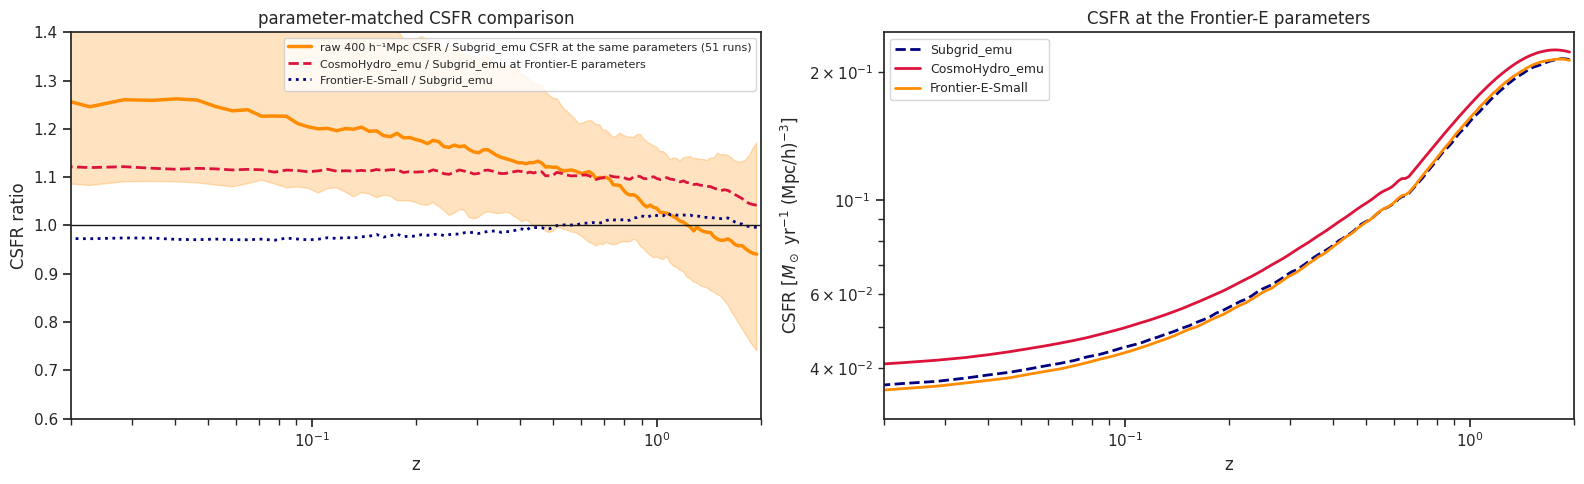

parameter-matched CSFR ratio (raw 400 / Subgrid_emu), median at z = 0, 0.5, 1, 2: ['1.277', '1.121', '1.036', '0.941']
CosmoHydro_emu / Subgrid_emu CSFR at Frontier-E params, z = 0, 0.5, 1, 2: ['1.121', '1.104', '1.097', '1.042']
Frontier-E-Small / Subgrid_emu CSFR, z = 0, 0.5, 1, 2: ['0.970', '0.996', '1.020', '0.996']
stars-in-galaxies / stars-formed fraction at the Frontier-E point: 400-suite fit 0.602, 128-suite fit 0.544, Frontier-E-Small 0.549


In [18]:
sg_csfr = sge.load_emulator('CSFR'); a_sg = np.asarray(sge.get_x_grid('CSFR')[0])
ch_csfr = ce.load_emulator('CSFR'); a_ch = np.asarray(ce.get_x_grid('CSFR')[0])
ag = np.linspace(0.34, 1.0, 120)                                              # z <= 2
raw_c = np.array([np.interp(ag, c[:, 0], c[:, 1]) for c in csfr_ch])[inbox]
pred_c = np.array([np.interp(ag, a_sg, sg_csfr.predict(q)[0]) for q in design[inbox, :5]])
r_c = raw_c / pred_c
lo, med, hi = np.nanpercentile(r_c, [16, 50, 84], axis=0)
m_sg_c = np.interp(ag, a_sg, sg_csfr.predict(P5)[0]); m_ch_c = np.interp(ag, a_ch, ch_csfr.predict(P7)[0])
fes_c = np.interp(ag, csfr_fes[:, 0], csfr_fes[:, 1])
fr_fit_ch, _ = quad_fit(design, fr_ch[:, None], np.array(P7)); fr_fit_sg, _ = quad_fit(P_sg, fr_sg[:, None], np.array(P5))

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(16, 5))
ax.fill_between(1/ag - 1, lo, hi, color='darkorange', alpha=0.25); ax.plot(1/ag - 1, med, color='darkorange', lw=2.5, label=f'raw 400 h⁻¹Mpc CSFR / Subgrid_emu CSFR at the same parameters ({inbox.sum()} runs)')
ax.plot(1/ag - 1, m_ch_c / m_sg_c, color='crimson', lw=2, ls='--', label='CosmoHydro_emu / Subgrid_emu at Frontier-E parameters')
ax.plot(1/ag - 1, fes_c / m_sg_c, color='navy', lw=2, ls=':', label='Frontier-E-Small / Subgrid_emu')
ax.axhline(1, color='k', lw=1); ax.set_xscale('log'); ax.set_xlim(0.02, 2); ax.set_ylim(0.6, 1.4); ax.set_xlabel('z'); ax.set_ylabel('CSFR ratio'); ax.legend(fontsize=8); ax.set_title('parameter-matched CSFR comparison')
ax2.plot(1/ag - 1, m_sg_c, color='navy', lw=2, ls='--', label='Subgrid_emu'); ax2.plot(1/ag - 1, m_ch_c, color='crimson', lw=2, label='CosmoHydro_emu'); ax2.plot(1/ag - 1, fes_c, color='darkorange', lw=2, label='Frontier-E-Small')
ax2.set_xscale('log'); ax2.set_yscale('log'); ax2.set_xlim(0.02, 2); ax2.set_xlabel('z'); ax2.set_ylabel(r'CSFR [$M_\odot$ yr$^{-1}$ (Mpc/h)$^{-3}$]'); ax2.legend(fontsize=9); ax2.set_title('CSFR at the Frontier-E parameters')
plt.tight_layout(); plt.show()
zi = lambda zz: np.argmin(np.abs(ag - 1/(1+zz)))
print('parameter-matched CSFR ratio (raw 400 / Subgrid_emu), median at z = 0, 0.5, 1, 2:', [f'{med[zi(zz)]:.3f}' for zz in [0, 0.5, 1, 2]])
print('CosmoHydro_emu / Subgrid_emu CSFR at Frontier-E params, z = 0, 0.5, 1, 2:', [f'{(m_ch_c / m_sg_c)[zi(zz)]:.3f}' for zz in [0, 0.5, 1, 2]])
print('Frontier-E-Small / Subgrid_emu CSFR, z = 0, 0.5, 1, 2:', [f'{(fes_c / m_sg_c)[zi(zz)]:.3f}' for zz in [0, 0.5, 1, 2]])
print(f'stars-in-galaxies / stars-formed fraction at the Frontier-E point: 400-suite fit {fr_fit_ch[0]:.3f}, 128-suite fit {fr_fit_sg[0]:.3f}, Frontier-E-Small {rho_g_fes / rho_c_fes:.3f}')

### G4. Cluster gas fractions (AGN-feedback sensitivity)

f_gas(M₅₀₀c) is the statistic most sensitive to the kinetic AGN feedback. The raw z = 0
`Mgas_M500_Ratio` extracts of the 400 h⁻¹Mpc runs (M_seed inside the subgrid box) are
compared with Subgrid_emu at the same parameters, and Frontier-E-Small with both fGas
emulators. A systematic offset here would point to feedback acting differently in the two
suites; agreement would leave the galaxy-level assignment as the prime suspect.

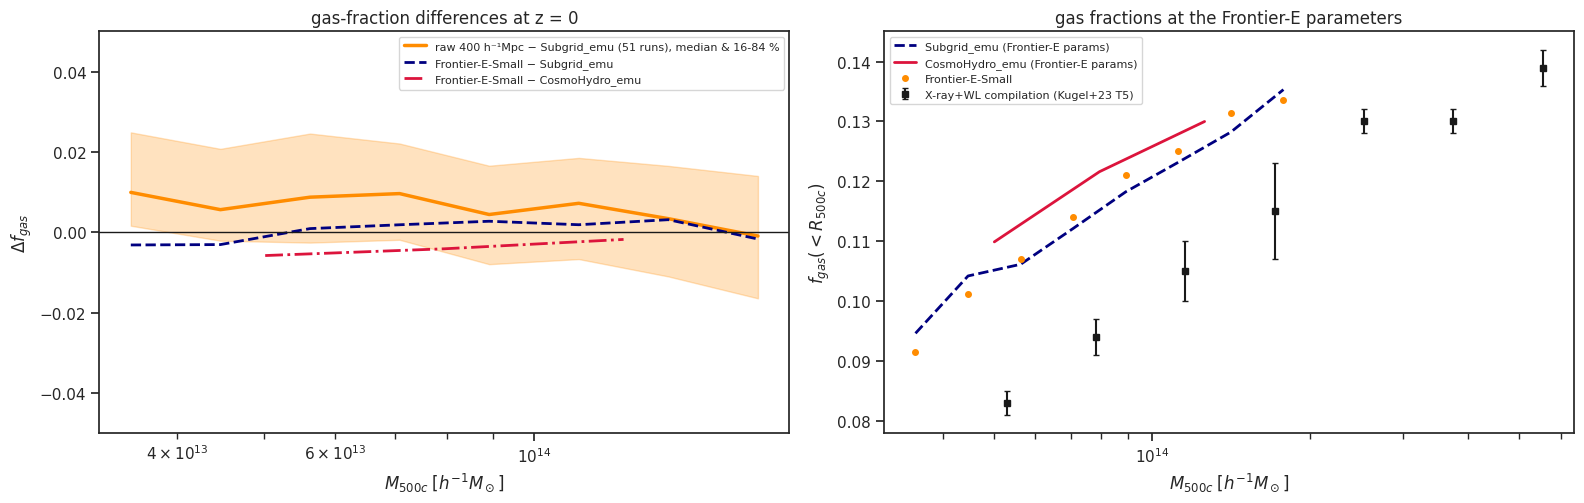

median (raw 400 − Subgrid_emu) f_gas at 10^13.5 / 10^14 / 10^14.5 Msun/h: [ 0.0099  0.0044 -0.0009]


In [19]:
sg_fg = sge.load_emulator('fGas'); xg_sg = np.asarray(sge.get_x_grid('fGas')[0])
ch_fg = ce.load_emulator('fGas'); xg_ch = np.asarray(ce.get_x_grid('fGas')[0])
def read_fgas(f, xg):
    d = np.loadtxt(f); ok = d[:, 3] > 0
    return np.interp(np.log10(xg), d[ok, 0], d[ok, 3], left=np.nan, right=np.nan)
fg_raw_ch = np.array([read_fgas(f'{CH_DIR}/RUN{i:03d}/extract/Mgas_M500_Ratio_624.txt', xg_sg) for i in np.where(inbox)[0]])
fg_sg_pred = rows(sg_fg.predict, design[inbox, :5])
d_fg = fg_raw_ch - fg_sg_pred
fg_fes_sg = read_fgas(f'{FES_DIR}/Mgas_M500_Ratio_624.txt', xg_sg); fg_fes_ch = read_fgas(f'{FES_DIR}/Mgas_M500_Ratio_624.txt', xg_ch)
m_sg_fes, _ = sg_fg.predict(P5); m_ch_fes, _ = ch_fg.predict(P7, z=0.0)

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(16, 5.2))
lo, med, hi = np.nanpercentile(d_fg, [16, 50, 84], axis=0)
ax.fill_between(xg_sg, lo, hi, color='darkorange', alpha=0.25); ax.plot(xg_sg, med, color='darkorange', lw=2.5, label=f'raw 400 h⁻¹Mpc − Subgrid_emu ({inbox.sum()} runs), median & 16-84 %')
ax.plot(xg_sg, fg_fes_sg - m_sg_fes, color='navy', lw=2, ls='--', label='Frontier-E-Small − Subgrid_emu')
ax.plot(xg_ch, fg_fes_ch - m_ch_fes, color='crimson', lw=2, ls='-.', label='Frontier-E-Small − CosmoHydro_emu')
ax.axhline(0, color='k', lw=1); ax.set_xscale('log'); ax.set_xlabel(r'$M_{500c}\;[h^{-1}M_\odot]$'); ax.set_ylabel(r'$\Delta f_{gas}$'); ax.set_ylim(-0.05, 0.05)
ax.set_title('gas-fraction differences at z = 0'); ax.legend(fontsize=8)
ax2.plot(xg_sg, m_sg_fes, color='navy', lw=2, ls='--', label='Subgrid_emu (Frontier-E params)')
ax2.plot(xg_ch, m_ch_fes, color='crimson', lw=2, label='CosmoHydro_emu (Frontier-E params)')
ax2.plot(xg_sg, fg_fes_sg, 'o', ms=4, color='darkorange', label='Frontier-E-Small')
fg_obs = obs.load_fgas_kugel2023(); ax2.errorbar(fg_obs['x'], fg_obs['y'], yerr=fg_obs['yerr'], fmt='s', ms=4, color='k', capsize=2, label=fg_obs['label'])
ax2.set_xscale('log'); ax2.set_xlabel(r'$M_{500c}\;[h^{-1}M_\odot]$'); ax2.set_ylabel(r'$f_{gas}(<R_{500c})$'); ax2.legend(fontsize=8); ax2.set_title('gas fractions at the Frontier-E parameters')
plt.tight_layout(); plt.show()
print('median (raw 400 − Subgrid_emu) f_gas at 10^13.5 / 10^14 / 10^14.5 Msun/h:',
      np.round([np.nanmedian(d_fg, 0)[np.argmin(np.abs(np.log10(xg_sg) - v))] for v in [13.5, 14.0, 14.5]], 4))

## Notes

### Where the CosmoHydro_emu excess comes from (section F)

- **The emulator is fine.** CosmoHydro_emu reproduces its own z = 0 training extracts
  to < 0.01 dex below 10¹¹ M☉ and to 0.03-0.06 dex (RMS) in the top two bins on the
  10 held-out runs (RUN100-109), i.e. the validation figure in
  `CosmoHydro/codes/02_train_emulators_multiz.ipynb` is genuine. Subgrid_emu reproduces
  its 64 training runs to 0.01-0.04 dex (0.07-0.11 dex in the top two bins, where the
  128 h⁻¹Mpc boxes hold few galaxies). Both packages train on `10**φ` and take log₁₀
  afterwards; the bundled training arrays match the raw extracts exactly.
- **The training simulations differ.** Evaluated at the *other* suite's design points,
  the raw 400 h⁻¹Mpc simulations sit +0.11 dex (10¹¹ M☉) and +0.18 dex (2.8×10¹¹ M☉)
  above Subgrid_emu, and CosmoHydro_emu sits +0.12 / +0.19 dex above the raw
  128 h⁻¹Mpc simulations — the same curve as the CosmoHydro_emu / Frontier-E excess.
  Below 3×10¹⁰ M☉ the two suites agree to 0.02 dex. The residual correlates only weakly
  with ωₘ (r = 0.24) and σ₈ (r = 0.35), so cosmology does not explain it, and the
  e_w-conditioned scatter (F4) shows the 400 h⁻¹Mpc runs above the 128 h⁻¹Mpc runs at
  the same feedback parameters at 10¹¹ and 2.8×10¹¹ M☉.
- **Emulator-free confirmation.** A ridge quadratic fitted to the raw 400 h⁻¹Mpc data
  evaluated at the Frontier-E parameters gives 1.29× and 1.68× the survey-scale
  Frontier-E GSMF at 10¹¹ and 2.8×10¹¹ M☉ — identical to the GP emulator — while the
  same fit to the 128 h⁻¹Mpc data gives 1.00× and 1.13×. The nearest 400 h⁻¹Mpc design
  points are also individually high at the massive end.
- **It is not a halo-level effect.** HMF_SOD / Tinker08 (each run at its own cosmology)
  is 0.82 for the 400 h⁻¹Mpc suite, 0.81 for the 128 h⁻¹Mpc suite and 0.83 for
  Frontier-E-Small over 10¹²-10¹⁴ M☉/h, and the CosmoHydro HMF emulator matches
  Frontier-E-Small to ≤ 4 % up to 10¹³ M☉/h. The haloes agree; the 400 h⁻¹Mpc runs put
  ~30-60 % more stellar mass into the most massive galaxies (or the galaxy finder /
  aperture mass differs). At z ≳ 0.5 the discrepancy is smaller (nb4), so it grows at
  late times.
- **What the section G tests say about the cause.**
  - *Not a mass-axis convention.* Expressed as a horizontal shift, the excess corresponds
    to Δ ≈ +0.08-0.11 dex above 4×10¹⁰ M☉ but −0.03 to −0.1 dex below 2×10¹⁰ M☉; a single
    best-fit shift (Δ = 0.092 dex, ×1.24 in mass) leaves a 0.03 dex residual of opposite
    sign at the two ends, and the h slip (0.17 dex) is excluded. Both HAVOCC configs use
    h = 0.6766 and identical mass bins.
  - *Redshift dependence is mixed.* At 10¹¹ M☉ the excess shrinks from 0.12 dex (z = 0)
    to 0.03 dex (z = 1); at 2.8×10¹¹ M☉ it stays at 0.19-0.22 dex for all z ≤ 1 and only
    disappears at z = 2 (raw 128 h⁻¹Mpc runs and Frontier-E-Small give the same picture).
    So the very massive end is already discrepant at z = 1, i.e. this is not a purely
    late-time quenching difference.
  - *Star-formation budget: two effects.* The design-averaged CSFR medians (G3) are
    misleading because the designs differ (M_seed range, cosmology). At **matched
    parameters** (G3b) the 400 h⁻¹Mpc runs form **more** stars at late times: raw 400 /
    Subgrid_emu CSFR = 1.28, 1.12, 1.04, 0.94 at z = 0, 0.5, 1, 2, and CosmoHydro_emu /
    Subgrid_emu = 1.12 at z = 0 at the Frontier-E point, whereas Frontier-E-Small /
    Subgrid_emu = 0.97-1.02 at all z. So late-time (z < 1) star formation is genuinely
    ~10-30 % higher in the 400 h⁻¹Mpc suite — weaker quenching. On top of that, the
    fraction of formed stars found in galaxies is higher (0.60 vs 0.54 at the Frontier-E
    point; 0.549 for Frontier-E-Small), i.e. a bookkeeping / assignment component as
    well. The extra late-time star formation lands in massive galaxies (the 10¹¹ M☉
    excess grows towards z = 0, G2), while the top-bin excess already present at z = 1
    fits the assignment component.
  - *Cluster gas fractions agree.* raw 400 h⁻¹Mpc f_gas − Subgrid_emu = +0.01 at
    10^13.5 M☉/h and ≈ 0 above 10¹⁴ M☉/h (inside the run-to-run scatter), and
    Frontier-E-Small sits within 0.005 of both emulators — the kinetic AGN feedback
    behaves the same in the two suites.
- **Next step (outside this repo).** The prime suspect is the cosmotools galaxy-finder
  configuration of the 400 h⁻¹Mpc campaign (`galaxy_aperture_radius`,
  `galaxy_dbscan_neighbors`, `galaxy_pmin`, `npart_threshold_galaxyproperties`; Frontier-E
  uses 50 / 10 / 10). The 400-suite `galaxyproperties` files live on OLCF
  (`/lustre/orion/cos006/proj-shared/SCIDAC_RUNS/RUNS/RUNxxx/analysis/galaxyproperties/`)
  and their headers carry these settings. For reference, the OpenCosmo headers of the
  128 h⁻¹Mpc suite (Perlmutter, 2024-08) and of Frontier-E both give
  aperture 50 / dbscan_neighbors 10 / galaxy_pmin 10 and NPERH_AGN = 2.25, so those two
  are consistent with each other; the 400 h⁻¹Mpc campaign was run and post-processed
  on OLCF Frontier (`/lustre/orion/cos006/...`, different machine and possibly
  different HACC/cosmotools builds) and is the one to check. The HAVOCC run for that
  suite did not produce
  the `ApertureStellarMass_DBScanStellarMass` or `StellarMass_HaloMass` extracts that would
  show the assignment directly. A secondary check is the HACC `indat.params` of a 400
  h⁻¹Mpc run against Frontier-E's (`data_sims/frontier_e/pk_hydro/indat.params`). Until
  this is resolved, the z = 0-1 GSMF from CosmoHydro_emu should not be used above
  ~4×10¹⁰ M☉ for calibration.

### Other findings

- **Subgrid_emu vs CosmoHydro_emu.** Same physics, same HAVOCC GSMF definition, same
  resolution and mass grid; they differ in the training suite (64 × 128 h⁻¹Mpc boxes at
  fixed cosmology vs 100 × 400 h⁻¹Mpc boxes that also vary ωₘ, σ₈ and cover z = 0-2).
- **Lever arms.** e_w dominates everywhere (0.22 dex across its range at both 10¹⁰ and
  10¹¹ M☉); κ_w and M_seed act only at the massive end (0.14-0.19 dex at 10¹¹, < 0.06 dex
  at 10¹⁰); v_kin and ε_kin barely move the z = 0 GSMF (≤ 0.05 dex), which is why the
  GSMF alone cannot calibrate the kinetic-AGN parameters — those come from fGas/CGD.
- **Cosmology.** Across the full (ωₘ, σ₈) box the GSMF moves by only 0.04 dex (≈ 10 %)
  at fixed subgrid parameters — comparable to the *weakest* subgrid parameters and 5× less
  than e_w. The z = 0 GSMF is essentially a subgrid probe; Subgrid_emu's fixed-cosmology
  assumption costs little here.
- **Targets.** GAMA, UniverseMachine, Frontier-E-Small and the survey-scale Frontier-E
  agree with each other to ≲ 0.1 dex over 10¹⁰-3×10¹¹ M☉. Below ~10¹⁰ M☉ the simulation
  and both emulators fall 10-20 % under UniverseMachine (resolution limit,
  m_gas = 2×10⁸ M☉/h). The UniverseMachine loader agrees with HAVOCC's own UM column to
  0.08 dex.
- **Survey-scale Frontier-E.** Three portal queries stitched together (section E) give the
  full-box GSMF from 3×10⁹ to 3×10¹² M☉ (8.0×10⁸ galaxies above 3×10⁹ M☉, 1.0×10⁷ above
  2×10¹¹). The capped queries are spatially uniform subsamples with sampling fractions
  0.0062 and 0.497, constant across mass to ±2 %; the M☉/h catalog convention is
  confirmed. Frontier-E-Small sits 1-3 % above the survey-scale run, Subgrid_emu within
  ±6 %, GAMA within ±5 % up to 2×10¹¹ M☉, UniverseMachine within ±18 %.

## Summary: why CosmoHydro_emu does not match at z = 0, and what to check

The GP emulator is faithful to its training data (F1); the **400 h⁻¹Mpc training
simulations themselves** have 30-60 % more galaxies above 10¹¹ M☉ than every other
CRK-HACC run at the same parameters (F2-F4). Ranked candidate causes:

| # | candidate | evidence here | what to check |
|---|---|---|---|
| 1 | **Weaker late-time quenching in the 400-suite runs** — HACC build or run parameters of the Frontier campaign (AGN radiative efficiency 0.2 in the HAVOCC config, `NPERH_AGN`, kinetic-jet implementation, softening `RSM`/`PROPER_RSM`, star-formation / wind code version) | at matched parameters the 400-suite CSFR is 1.28× (z = 0), 1.12× (z = 0.5), 1.04× (z = 1) the 128-suite value while Frontier-E-Small matches the 128 suite (G3b); the 10¹¹ M☉ excess grows towards z = 0 (G2); f_gas nevertheless agrees (G4), so the difference is in how AGN energy couples to star formation, not in gas ejection | diff a 400-run `indat.params` against `data_sims/frontier_e/pk_hydro/indat.params` (all `AGN_*`, `NPERH_AGN`, `RSM`, SF/wind keys); HACC commit hashes of both campaigns |
| 2 | **Galaxy finder / stellar-mass assignment** differs in the 400-suite cosmotools run (DBSCAN neighbours, `galaxy_pmin`, 50 kpc aperture, particle threshold, cosmotools build) | a larger fraction of formed stars is found in galaxies (0.60 vs 0.54 at the Frontier-E point, G3b); top-bin excess already present at z = 1 when the CSFR difference is only 4 % (G2); HMF agrees (F5) | headers of `RUNxxx/analysis/galaxyproperties/` on OLCF (`galaxy_aperture_radius`, `galaxy_dbscan_neighbors`, `galaxy_pmin`, `npart_threshold_galaxyproperties`); cosmotools git version; compare with Frontier-E / 128-suite (50 / 10 / 10) |
| 3 | **Satellite / ICL bookkeeping** (stars outside apertures, merged satellites) | massive-end excess already present at z = 1, persists to z = 0 (G2) | `ApertureStellarMass_DBScanStellarMass`, `StellarMass_HaloMass(_Central/_Satellite)` HAVOCC modules re-run on one 400 box; compare central vs satellite GSMF |
| 4 | Parameter **unit / scaling mismatch** in the design (M_seed ×10⁶, v_kin ×10⁴, ε_kin ×10, e_w) | argues against: both suites respond to e_w, κ_w the same way (F4), f_gas agrees (G4) | confirm the values written in the 400-run `indat.params` equal `FinalDesign.txt` × scale factors |
| 5 | **Mass-axis convention** (M☉/h vs M☉, aperture in comoving vs proper units) | excluded: not a single shift, h slip (0.17 dex) far too large (G1); both configs use h = 0.6766 | none needed |
| 6 | **Cosmology handling** (ωₘ varied at fixed h; Tinker/HMF per-run cosmology) | excluded: residual correlates weakly with ωₘ, σ₈ (r ≤ 0.35); HMF/Tinker agrees (F2, F5) | none needed |
| 7 | **Box size / resolution** | excluded: same particle mass; the 256 and 3150 h⁻¹Mpc runs agree with the 128 h⁻¹Mpc suite; HMF agrees | none needed |
| 8 | **Emulator / training pipeline** (10**φ transform, PCA truncation, NaN filling, z interpolation) | excluded at z = 0: hold-out RMS ≤ 0.06 dex, in-sample ≤ 0.01 dex below 10¹¹ M☉ (F1) | none needed for the GSMF; the same transform quirk (`10**φ`) is worth tidying but is not the cause |

**Practical consequence:** until 1-3 are resolved, treat CosmoHydro_emu's GSMF above
~4×10¹⁰ M☉ at z ≤ 1 as biased high by 0.1-0.2 dex; the HMF, f_gas and (from nb2/nb3)
Pk emulators are unaffected. Subgrid_emu is the safer z = 0 GSMF reference.